# **Probabilistic Machine-Learning (PML) Analysis**

## Unified materialized view containing all calculated stock features

### Covers 26 feature categories from 63 calc_* functions:

1. Valuation Ratios (4 functions)
2. Momentum (2 functions)
3. Technical Analysis (1 function)
4. Profitability (4 functions)
5. Earnings (6 functions)
6. Growth (5 functions)
7. Quality & Risk (5 functions)
8. Leverage & Liquidity (6 functions)
9. Analyst Sentiment (2 functions)
10. Dividends (3 functions)
11. Employment (2 functions)
12. Cash Flow (4 functions)
13. Temporal (2 functions)
14. Balance Sheet (3 functions)
15. Cost Structure (3 functions)
16. Composite Scores (2 functions)
17. Unusual Items (1 function)
18. Volatility Surface (1 function) - Enhancement 2+3
19. Tax Rate Features (1 function) - Enhancement 4
20. OpEx Temporal (1 function) - Enhancement 5
21. Asset Sale Features (1 function) - Enhancement 8
22. FCF Estimate Curve (1 function) - Enhancement 9
23. Dividend History (1 function) - Enhancement 10
24. Investment Income Temporal (1 function) - Enhancement 11
25. Share Dilution Tracking (1 function) - Enhancement 12
26. Forward Consensus (1 function) - Enhancement 7

Direct reference columns include: Enhancement 1 (17 cols), Enhancement 6 (6 cols),

## 1. Setup & Data Loading

In [71]:
# ── Configure PyTensor to use Python-only mode (must run before any PyMC import) ──
# On Windows with MSVC-built CPython 3.14, MinGW g++ cannot reliably link against
# python314.dll due to ABI incompatibility.  Setting cxx="" disables C compilation
# entirely and uses PyTensor's pure-Python VM.
import os

os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="

In [72]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from probabilistic_ml_model.statistical_functions.screening import (
    create_enhanced_screener,
    screen_value_opportunities,
    screen_growth_momentum,
    screen_dividend_quality,
    screen_financial_health,
    rank_stocks_by_composite_score,
)
from probabilistic_ml_model.statistical_functions.statistical_models import (
    bayesian_category_analysis,
    fit_distributions_by_category,
    detect_accounting_anomalies,
    kalman_filter_price_target,
    monte_carlo_price_target_simulation,
    analyze_distress_distribution,
)

# Core PML Models (Bayesian / PyMC)
from probabilistic_ml_model.pml_models.AccountingAnomalyModel import AccountingAnomalyBayesian
from probabilistic_ml_model.pml_models.CreditRiskModel import CreditRiskBayesian
from probabilistic_ml_model.pml_models.DividendSafetyModel import DividendSafetyBayesian
from probabilistic_ml_model.pml_models.EarningsBeatModel import EarningsBeatBayesian
from probabilistic_ml_model.pml_models.KalmanFilterModel import KalmanFilterPriceTarget
from probabilistic_ml_model.pml_models.MonteCarloSimulation import MonteCarloReturnSimulation
from probabilistic_ml_model.pml_models.PriceTargetModel import PriceTargetAchievement

import arviz as az
from probabilistic_ml_model.visualizations.probability_viz import (
    create_posterior_return_forest,
    create_beat_probability_posterior,
    create_mcse_convergence_panel,
    create_mcmc_anomaly_posterior_chart,
    create_mcmc_credit_risk_chart,
    create_mcmc_dividend_cut_chart,
    create_mcmc_price_target_chart,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

COLORS = {
    "primary": "#264653",
    "secondary": "#2A9D8F",
    "accent": "#E9C46A",
    "danger": "#E76F51",
    "info": "#457B9D",
    "light": "#F4A261",
}

## 2. Data Overview & Quality Assessment

In [73]:
%%sql
select * from public.mv_all_stock_features masf

,isin,ticker,name,description,region,country,trading_country,exchange,sector,industry,dividend_record_frequency,earnings_report_frequency,fy_end,next_earnings_report,next_earnings_status,next_earnings_when,next_fiscal_quarter,reporting_interval,size_class,style_class,unit,dividend_record_announce_date,dividend_record_ex_date,dividend_record_payable_date,dividend_record_record_date,fy_end_date,income_statement_report_date,last_updated,next_earnings,next_fy_end_date,...,fcf_est_avg_fy4e,fcf_est_avg_fy5e,fcf_est_cagr_5y,fcf_est_trend,div_yield_2fyind,div_yield_3fyind,div_yield_4fyind,div_yield_5fyind,div_yield_5y_trend,div_yield_stability,interest_income_fq,interest_income_fy,interest_income_qoq_growth,interest_income_yoy_growth,interest_income_to_revenue_trend,shares_yoy_change_pct,net_buyback_flag,pe_ntm,pe_est_fy1,pe_forward_discount,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ebitda_est_ntm,ebitda_est_fy1e,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy,feature_calculated_at
0,US0378331005,AAPL,Apple Inc.,Apple Inc. designs manufactures and markets sm...,United States and Canada,US,US,NasdaqGS,Information Technology,Technology Hardware Storage and Peripherals,Quarterly,Quarterly,Sep 2025,Interim,Estimated,After-Market,Q3 2026,3.0000,Large Cap,Core,USD,2026-01-29,2026-02-09,2026-02-12,2026-02-09,2025-09-30,2025-12-27,2026-04-14,2026-04-30,2026-09-30,...,175520.5800,188318.0400,8.1096,0.3660,0.0056,0.0061,0.0060,0.0073,-0.0007,0.0021,0.0000,0.0000,NaN,NaN,0.0000,-0.0344,1,30.1000,30.3000,-0.1301,-0.0300,-0.0200,-0.0100,162027.0400,163054.5800,22.9000,0.0664,-0.0003,-0.0879,2026-04-14 20:19:13.449149+02
1,US67066G1040,NVDA,NVIDIA Corporation,NVIDIA Corporation operates as a data center s...,United States and Canada,US,US,NasdaqGS,Information Technology,Semiconductors and Semiconductor Equipment,Quarterly,Semi-Annually,Jan 2026,Half Year,Confirmed,After-Market,Q2 2028,6.0000,Large Cap,Growth,USD,2026-02-25,2026-03-11,2026-04-01,2026-03-11,2026-01-31,2026-01-25,2026-04-14,2026-05-20,2027-01-31,...,376909.5000,410181.5000,22.7368,1.2693,0.0003,0.0008,0.0007,0.0012,-0.0002,0.0006,568.0000,2300.0000,-0.0897,0.2878,0.0107,-0.0079,1,23.5000,23.5000,-0.4081,-0.1500,-0.1500,0.0000,250616.1900,250616.1900,18.7000,0.8811,-0.0677,-0.7033,2026-04-14 20:19:13.449149+02
2,AU0000237554,ALL,Atlantic Lithium Limited,Atlantic Lithium Limited engages in the explor...,Asia / Pacific,AU,GB,AIM,Materials,Metals and Mining,NaN,Semi-Annually,Jun 2025,Full Year,Estimated,Pre-Market,Q4 2026,6.0000,Small Cap,Core,GBP,NaN,NaN,NaN,NaN,2025-06-30,2025-12-31,2026-04-13,2026-06-11,2026-06-30,...,0.0000,0.0000,NaN,-1.0000,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,0.0000,0.2337,0,NaN,NaN,NaN,0.0100,0.0100,NaN,-4.7600,-4.7600,NaN,0.4691,NaN,NaN,2026-04-14 20:19:13.449149+02
3,US02079K3059,GOOGL,Alphabet Inc.,Alphabet Inc. offers various products and plat...,United States and Canada,US,US,NasdaqGS,Communication Services,Interactive Media and Services,Quarterly,Semi-Annually,Dec 2025,Half Year,Confirmed,After-Market,Q2 2027,6.0000,Large Cap,Core,USD,2026-02-04,2026-03-09,2026-03-16,2026-03-09,2025-12-31,2025-12-31,2026-04-14,2026-04-29,2026-12-31,...,151712.3500,192694.1000,71.7693,7.7053,NaN,NaN,NaN,NaN,NaN,0.0017,1209.0000,4337.0000,0.1236,-0.0324,0.0108,-0.0118,1,28.7000,28.7000,-0.0651,-0.1400,-0.1400,-0.0400,218126.6200,218126.6200,18.1000,0.4525,0.0067,0.1299,2026-04-14 20:19:13.449149+02
4,US47103J1051,JANX,Janux Therapeutics Inc.,Janux Therapeutics Inc. a clinical stage bioph...,United States and Canada,US,US,NasdaqGM,Health Care,Biotechnology,NaN,Semi-Annually,Dec 2025,Half Year,Estimated,After-Market,Q2 2027,6.0000,Small Cap,Core,USD,NaN,NaN,NaN,NaN,2025-12-31,2025-12-31,2026-04-14,2026-05-08,2026-12-31,...,-350.3700,-293.1300,NaN,0.7946,NaN,NaN,NaN,NaN,NaN,NaN,10.4600,44.0400,-0.0439,0.4754,4.4040,0.0551,0,NaN,NaN,NaN,-0.0400,-0.0400,-0.0400,-189.3000,-189.3000,0.1000,0.2163,NaN,N

In [74]:
%%sql
select cfr.category,cfr.feature_alias, cfr.calculation_type from public.calculated_features_registry cfr
where category <> 'Identifier' and category <> 'Market Data';

,category,feature_alias,calculation_type
0,Interest Income,interest_income_yoy_growth,growth
1,Dividend Reliability,div_yield_mean_5y,score
2,Dividend Reliability,div_yield_vs_5y_mean,ratio
3,Momentum & Technical,market_cap,direct
4,Momentum & Technical,market_cap_country_r,direct
...,...,...,...
802,Leverage & Liquidity,wc_fy,direct
803,Leverage & Liquidity,wc_improving_flag,flag
804,Leverage & Liquidity,wc_ltm,direct
805,Leverage & Liquidity,wc_vs_5y_avg,direct


In [75]:
# Build a proper dictionary from the DataFrame: {category: [feature_alias, ...]}
FEATURE_CATEGORIES = feature_cat.groupby("category")["feature_alias"].apply(list).to_dict()

print(f"Dataset shape: {df.shape[0]} stocks × {df.shape[1]} features")
print(f"Feature categories: {len(FEATURE_CATEGORIES)}")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")

Dataset shape: 6677 stocks × 818 features
Feature categories: 27

Column dtypes:
float64    675
int64      109
str         34
Name: count, dtype: int64


In [76]:
# Identifier columns overview
id_cols = ["ticker", "name", "industry", "sector", "next_earnings"]
available_ids = [c for c in id_cols if c in df.columns]
print("Identifier columns available:", available_ids)
df[available_ids].head(10)

Identifier columns available: ['ticker', 'name', 'industry', 'sector', 'next_earnings']


,ticker,name,industry,sector,next_earnings
0,AAPL,Apple Inc.,Technology Hardware Storage and Peripherals,Information Technology,2026-04-30
1,NVDA,NVIDIA Corporation,Semiconductors and Semiconductor Equipment,Information Technology,2026-05-20
2,ALL,Atlantic Lithium Limited,Metals and Mining,Materials,2026-06-11
3,GOOGL,Alphabet Inc.,Interactive Media and Services,Communication Services,2026-04-29
4,JANX,Janux Therapeutics Inc.,Biotechnology,Health Care,2026-05-08
5,TSLA,Tesla Inc.,Automobiles,Consumer Discretionary,2026-04-22
6,PHAT,Phathom Pharmaceuticals Inc.,Pharmaceuticals,Health Care,2026-05-14
7,LLY,Eli Lilly and Company,Pharmaceuticals,Health Care,2026-04-30
8,INTEK,Ideal Holdings S.A.,Electronic Equipment Instruments and Components,Information Technology,2026-04-28
9,XOM,Exxon Mobil Corporation,Oil Gas and Consumable Fuels,Energy,2026-05-01


In [77]:
# Missing data analysis per feature category
missing_report = {}
for cat, cols in FEATURE_CATEGORIES.items():
    present = [c for c in cols if c in df.columns]
    if present:
        pct_missing = df[present].isnull().mean().mean() * 100
        missing_report[cat] = {
            "defined": len(cols),
            "present": len(present),
            "avg_missing_pct": round(pct_missing, 1),
        }

missing_df = pd.DataFrame(missing_report).T.sort_values("avg_missing_pct", ascending=False)
missing_df

,defined,present,avg_missing_pct
Employee Productivity,7.0000,7.0000,28.3000
Dividend Reliability,34.0000,31.0000,23.9000
Valuation Timeseries,23.0000,22.0000,15.7000
EPS Trajectory,11.0000,11.0000,13.4000
GAAP vs Adjusted,50.0000,50.0000,13.1000
Employment Dynamics,10.0000,10.0000,12.9000
Efficiency Ratios,45.0000,45.0000,11.5000
Enhanced Cash Flow,28.0000,28.0000,9.4000
Valuation Ratios,17.0000,16.0000,8.7000
Analyst Sentiment,30.0000,23.0000,8.6000


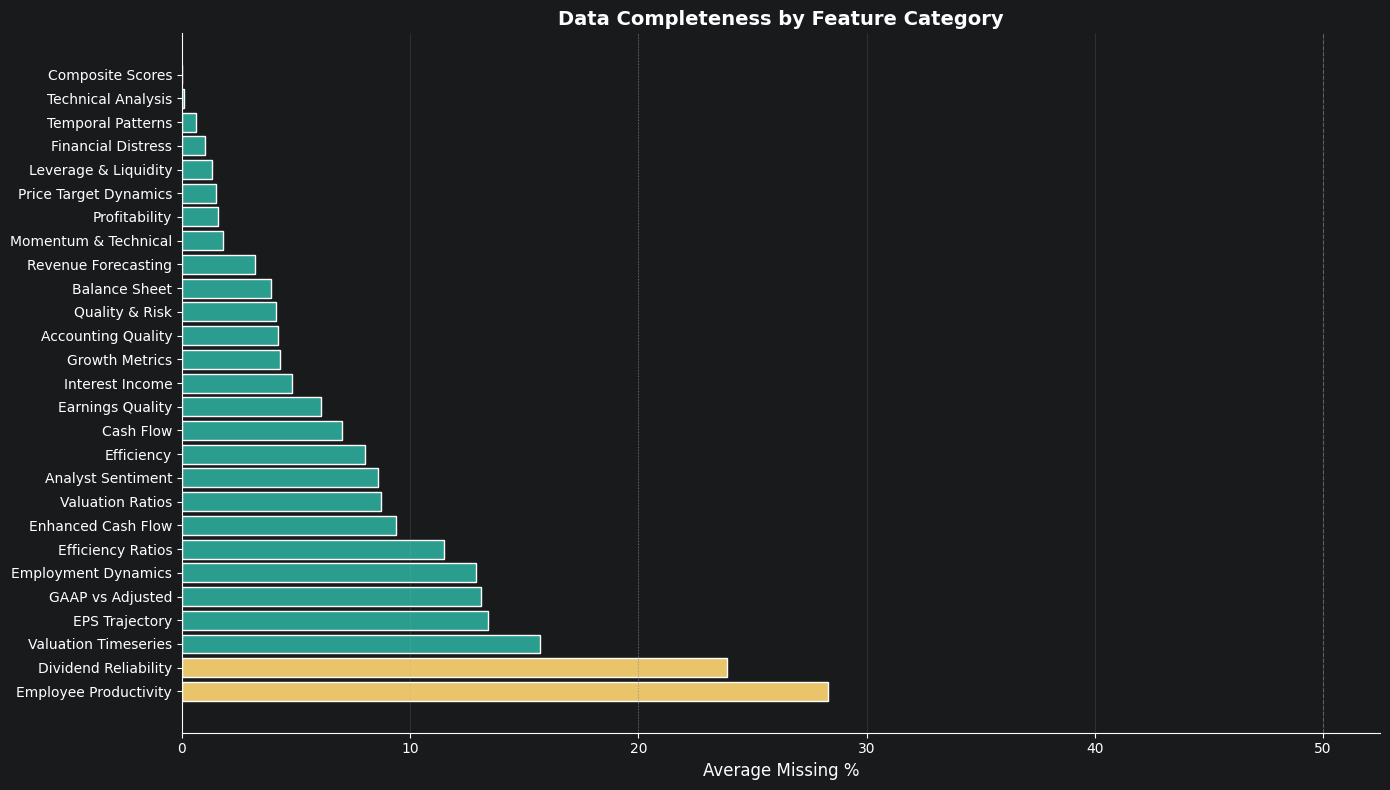

In [78]:
# Visualize missing data by category
fig, ax = plt.subplots(figsize=(14, 8))
colors_bar = [
    COLORS["danger"] if v > 50 else COLORS["accent"] if v > 20 else COLORS["secondary"]
    for v in missing_df["avg_missing_pct"]
]
bars = ax.barh(missing_df.index, missing_df["avg_missing_pct"], color=colors_bar, edgecolor="white")
ax.set_xlabel("Average Missing %", fontsize=12)
ax.set_title("Data Completeness by Feature Category", fontsize=14, fontweight="bold")
ax.axvline(20, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
ax.axvline(50, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Descriptive Statistics by Feature Category

In [79]:
# Summary statistics for each category
for cat_name in FEATURE_CATEGORIES:
    cols = [c for c in FEATURE_CATEGORIES.get(cat_name, []) if c in df.columns]
    if cols:
        print(f"\n{'=' * 60}")
        print(f"  {cat_name} ({len(cols)} features)")
        print(f"{'=' * 60}")
        display(df[cols].describe().round(3))


  Accounting Quality (46 features)


,goodwill_change_rate,restructuring_intensity,exceptional_items_frequency,merger_impact_ratio,non_operating_income_share,asset_sale_boost,accounting_quality_score,asset_sale_frequency,asset_sale_trend,effective_tax_rate_fy,tax_rate_yoy_change,tax_rate_qoq_change,tax_rate_stability,low_tax_flag,tax_rate_trend_4q,effective_tax_rate_ltm,asset_sale_gain_loss_ltm,goodwill_1fy,goodwill_2fq,goodwill_2fy,goodwill_3fq,goodwill_3fy,goodwill_3y_growth,goodwill_4fq,goodwill_4fy,goodwill_accumulation_rate,goodwill_concentration,goodwill_fy,goodwill_ltm,goodwill_qoq_change,goodwill_to_assets_trend,goodwill_vs_5y_avg,goodwill_yoy_change,impairment_risk_score,recent_acquisition_flag,asset_writedown_frequency,asset_writedown_ltm,exceptional_items_total_ltm,goodwill_impairment_frequency,goodwill_impairment_ltm,has_goodwill_impairment_ltm,quality_issues_count_5y,restructuring_frequency,restructuring_ltm,goodwill_1fq,goodwill_fq
count,4739.0000,6321.0000,6677.0000,6677.0000,6671.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,4601.0000,6677.0000,6677.0000,4601.0000,6638.0000,6677.0000,6677.0000,4098.0000,6534.0000,4831.0000,4739.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000
mean,2.1160,-0.0020,0.5780,-0.0040,0.2750,0.2910,85.9110,4.1230,-1.6150,0.2300,-0.0360,-0.0690,0.4630,0.3250,-0.0390,0.2590,8.3410,1130.2130,1087.8510,1115.0180,1026.5870,1074.9940,563.8970,1095.5070,1049.0470,4.7360,24.5510,1191.7040,1174.8850,3.1850,-0.1820,1.0070,219.3690,17.0590,0.0180,1.9760,-30.3640,72.1660,0.4000,-15.3110,0.0790,3.2690,0.8930,-22.2740,1091.1970,1174.8000
std,85.4810,0.0070,0.6990,0.0330,2.5840,0.4540,16.9960,3.8450,220.1420,1.1440,2.9080,4.3100,5.2230,0.4680,1.8900,2.0430,225.7340,4918.6930,4983.9680,4677.1430,4661.3400,4526.2510,11806.7320,4913.2260,4542.7800,71.8340,219.0370,5108.6830,5128.1730,180.4510,3.8810,5.4670,8558.7150,29.6310,0.1320,2.0290,306.5590,489.5730,0.9270,188.7520,0.2700,3.0920,1.6670,291.2230,4816.2140,5128.1880
min,-3.2210,-0.1830,0.0000,-1.5170,0.0000,0.0000,20.0000,0.0000,-13005.0720,0.0000,-202.6670,-305.7730,0.0000,0.0000,-100.9120,0.0000,-11049.1100,0.0000,-1.0100,0.0000,-1.0700,0.0000,-100.0000,-0.0400,0.0000,-100.0000,-11438.3840,-1.0100,-1.9100,-100.0000,-63.9160,0.0000,-217.4420,0.0000,0.0000,0.0000,-16440.3400,0.0000,0.0000,-6734.0000,0.0000,0.0000,0.0000,-20197.3700,-1.7800,-1.9100
25%,-0.0190,0.0000,0.0000,-0.0000,0.0130,0.0000,75.0000,0.0000,-0.0280,0.0000,-0.0360,-0.0290,0.0220,0.0000,-0.0540,0.0110,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-11.2170,0.0000,0.0000,-3.8880,0.0000,0.0000,0.0000,-0.4470,-0.3080,0.4610,-1.5280,0.0000,0.0000,0.0000,-2.2800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0340,0.0000,0.0000,0.0000,0.0530,0.0000,90.0000,4.0000,0.0000,0.1650,0.0000,0.0000,0.0880,0.0000,0.0000,0.1930,0.0000,39.5500,14.3000,36.8100,15.4700,30.8300,2.0710,24.3400,25.6900,0.6860,2.5290,39.3200,26.4000,0.0560,0.0000,1.0000,2.6340,2.5700,0.0000,1.0000,0.0000,0.1600,0.0000,0.0000,0.0000,3.0000,0.0000,0.0000,17.9100,26.3700
75%,0.1290,0.0000,1.0000,0.0000,0.1470,1.0000,100.0000,8.0000,0.0020,0.2610,0.0180,0.0190,0.2500,1.0000,0.0270,0.2620,0.1000,431.1500,335.9000,423.7600,326.9400,392.5600,25.9590,373.3600,357.4500,7.9960,32.0960,468.0700,419.6500,0.7900,0.0360,1.1530,12.5820,17.7690,0.0000,4.0000,0.0000,14.9300,0.0000,0.0000,0.0000,5.0000,1.0000,0.0000,359.8700,419.6500
max,4258.4170,0.0200,3.0000,0.0440,178.5450,1.0000,100.0000,10.0000,9583.0000,62.0000,61.6920,38.8360,307.5180,1.0000,38.8560,142.9370,9672.0000,119220.0000,119509.0000,117043.0000,119329.0000,113010.0000,448259.6490,119191.0000,115796.0000,1548.9550,9991.1070,119509.0000,119622.0000,7290.3770,43.6460,376.6670,425841.6670,100.0000,1.0000,5.0000,1574.6700,20197.3700,5.0000,498.3400,1.0000,15.0000,5.0000,95.1900,119497.0


  Analyst Sentiment (23 features)


,ebitda_est_fy1e,analyst_bullish_pct,analyst_bearish_pct,upside_potential,price_target_spread_pct,price_target_revision_1m,price_target_revision_3m,eps_revision_momentum,analyst_coverage_quality,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy,pe_forward_discount,pe_est_fy1,ebitda_est_ntm,pe_ntm,analyst_neutral_pct,analyst_rating_normalized,analyst_conviction
count,6677.0000,6592.0000,6674.0000,6677.0000,6677.0000,6645.0000,6575.0000,6677.0000,6677.0000,5563.0000,5492.0000,3460.0000,6082.0000,6624.0000,4614.0000,5257.0000,5046.0000,5811.0000,6677.0000,5851.0000,6674.0000,6677.0000,6674.0000
mean,1665.3720,67.0970,6.1040,25.6000,40.4080,0.0090,0.0630,0.0600,1.0110,-0.2530,-0.2190,-0.8530,14.8850,0.0290,-0.0260,-0.0590,-0.1340,26.5540,1707.0660,26.2060,25.6750,75.6790,62.3040
std,8344.1410,30.9970,13.9080,40.6660,38.4850,0.0870,0.2230,2.0390,0.7450,3.7500,1.4070,3.6440,21.8520,7.3050,1.9380,1.4890,1.2110,36.6520,8737.4210,36.8450,26.3750,21.2440,32.4610
min,-2731.1500,0.0000,0.0000,-95.5600,0.0000,-0.9950,-0.9910,-0.8300,0.0920,-260.4600,-16.5100,-62.7400,0.0000,-274.0850,-59.0080,-1.0000,-1.0000,1.1000,-2731.1500,0.0000,0.0000,-25.0000,0.0000
25%,88.6900,47.3680,0.0000,5.3680,16.0640,-0.0090,-0.0320,-0.0210,0.4120,-0.1300,-0.1400,-0.9200,6.5000,0.0320,-0.0110,-0.4740,-0.4120,12.0000,91.4000,11.9000,0.0000,65.7500,38.0950
50%,346.4000,73.3330,0.0000,18.3570,35.5560,0.0000,0.0150,0.0000,0.8510,-0.0100,-0.0100,-0.0400,9.6000,0.1860,0.0000,-0.2130,-0.2120,17.2000,355.7100,17.0000,20.0000,79.2500,66.6670
75%,1082.7300,100.0000,7.1430,35.7770,55.1110,0.0110,0.1110,0.0230,1.4650,0.0000,0.0000,0.0300,15.3000,0.4460,0.0200,0.0470,-0.0690,27.3000,1104.1500,26.9000,42.8570,90.5000,96.1150
max,250616.1900,100.0000,100.0000,663.3590,893.0000,1.6620,3.5310,160.5720,4.5520,48.9100,49.0700,60.6700,411.0000,134.5190,89.7670,59.6710,42.0310,494.6000,250616.1900,494.6000,100.0000,100.0000,100.0000



  Balance Sheet (51 features)


...

,fiscal_quarter,fiscal_month,fiscal_year,days_to_earnings,earnings_report_recency,reporting_lag,fiscal_year_progress,days_since_last_report,days_to_fy_end,earnings_season_flag,fiscal_quarter_progress,is_fy_end_month,is_quarter_end_month,post_earnings_window,pre_earnings_window,reporting_freshness_score
count,6570.0000,6570.0000,6570.0000,6677.0000,6671.0000,6671.0000,6570.0000,6671.0000,6572.0000,6677.0000,6570.0000,6677.0000,6677.0000,6677.0000,6677.0000,6677.0000
mean,3.5740,10.7150,2025.9230,26.4650,119.1980,145.6590,0.8930,119.1980,-182.0910,1.0000,0.9980,0.0060,0.0000,0.0000,0.2750,1.1200
std,0.7640,2.3010,0.3710,25.1060,78.8420,82.3070,0.1920,78.8420,144.1390,0.0000,0.0350,0.0800,0.0000,0.0000,0.4470,7.2890
min,1.0000,2.0000,2013.0000,-1.0000,14.0000,13.0000,0.1670,14.0000,-4852.0000,1.0000,0.3330,0.0000,0.0000,0.0000,0.0000,0.0000
25%,3.0000,9.0000,2026.0000,14.0000,104.0000,119.0000,0.7500,104.0000,-288.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,4.0000,12.0000,2026.0000,21.0000,104.0000,127.0000,1.0000,104.0000,-104.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,4.0000,12.0000,2026.0000,29.0000,104.0000,139.0000,1.0000,104.0000,-104.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
max,4.0000,12.0000,2027.0000,192.0000,4579.0000,4607.0000,1.0000,4579.0000,-45.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,100.0000



  Valuation Ratios (16 features)


,p_e_ratio,p_b_ratio,ev_ebitda_ratio,ev_sales_ratio,peg_ratio,valuation_dividend_yield,tangible_book_per_share,price_to_tangible_book,tangible_equity_ratio,intangibles_to_equity,tangible_asset_quality,tangible_book_value_fy,tangible_book_value_ltm,tbv_vs_calculated,tbv_yoy_growth,goodwill_to_equity
count,5227.0000,6376.0000,5989.0000,6494.0000,4369.0000,4203.0000,6677.0000,5346.0000,6321.0000,6638.0000,6677.0000,6677.0000,6677.0000,6638.0000,6644.0000,6638.0000
mean,38.7160,5.0470,19.6220,5.6990,0.3500,0.0320,0.0000,8.9160,28.1710,44.0630,83.9300,2362.7830,2398.9590,0.3930,3.2700,24.5510
std,52.5000,10.5570,33.9340,20.4900,13.5540,0.0520,0.0000,21.9760,50.3560,1528.2540,23.2520,13742.7400,13924.1890,49.0880,89.4330,219.0370
min,0.0000,0.1000,0.1000,0.0000,-102.6180,0.0000,-0.0010,0.2000,-2800.0000,-6234.3430,0.0000,-91551.0000,-91551.0000,-3674.5000,-1704.4740,-11438.3840
25%,14.8000,1.5000,7.3000,1.1000,-1.4840,0.0110,0.0000,1.9000,7.9770,0.0000,76.3930,54.2000,52.9000,0.7640,0.0000,0.0000
50%,22.4000,2.6000,11.0000,2.2000,0.3480,0.0230,0.0000,3.6000,30.2650,0.1780,95.7270,518.2300,522.2600,0.9620,0.0000,2.5290
75%,39.8500,5.2000,18.5000,4.6000,1.6990,0.0410,0.0000,8.0000,52.6210,18.2110,100.0000,1953.0000,1957.3500,1.0020,0.0000,32.0960
max,493.1000,422.7000,499.7000,494.6000,334.1080,1.8360,0.0210,480.1000,99.9320,120671.4290,100.0000,381885.0000,381885.0000,1482.1670,3983.1170,9991.1070



  Valuation Timeseries (22 features)


,ev_sales_forward_discount,ev_ebitda_forward_discount,p_b_vs_5y_avg,ev_sales_qoq_1q,p_b_momentum_yoy,forward_pe_premium,ev_sales_trend_1y,ev_ebitda_momentum,p_e_momentum_yoy,p_e_momentum_qoq,ev_sales_vs_3y_avg,ev_ebitda_vs_3y_avg,p_e_vs_3y_avg,p_e_forward_discount,ev_ebitda_qoq_trend,ev_sales_qoq_2q,ev_sales_qoq_4q,p_e_percentile_proxy,p_e_vs_5y_avg,valuation_compression,valuation_mean_reversion,ev_sales_qoq_3q
count,6359.0000,5808.0000,5479.0000,6459.0000,6331.0000,5030.0000,6433.0000,5940.0000,5183.0000,5193.0000,6062.0000,5551.0000,4815.0000,5030.0000,5957.0000,6493.0000,6459.0000,4815.0000,4493.0000,4750.0000,4745.0000,6461.0000
mean,-0.0710,-0.1170,1.1390,0.0970,0.1280,-14.2040,0.1480,0.1920,0.1830,0.2920,0.1440,0.1170,0.2310,-0.1420,0.3780,0.3160,0.0680,0.4610,0.2410,0.1590,0.1540,0.5310
std,0.9550,0.7030,0.7720,0.6400,0.6480,104.8430,2.1400,5.1370,1.1150,1.6210,0.5610,0.6420,0.9890,1.0480,17.1130,18.7330,3.6650,1.9770,1.2160,0.6350,0.5340,28.3310
min,-1.0000,-0.9840,0.0360,-1.0000,-0.9600,-98.5660,-1.0000,-0.9820,-1.0000,-1.0000,-1.0000,-0.9860,-1.0000,-0.9860,-0.9590,-1.0000,-1.0000,-2.0000,-1.0000,-0.9090,-0.8500,-0.9980
25%,-0.1670,-0.2740,0.7050,-0.1050,-0.0700,-39.7760,-0.0570,-0.0650,-0.0690,-0.1230,-0.1540,-0.1880,-0.2270,-0.3980,-0.1160,-0.0750,-0.1900,-0.4540,-0.3070,-0.1900,-0.1580,0.0000
50%,-0.0770,-0.1320,1.0000,0.0000,0.0060,-19.8560,0.0000,0.0150,0.0250,0.0360,0.0000,0.0040,0.0320,-0.1990,0.0130,0.0000,0.0000,0.0630,-0.0050,0.0270,0.0430,0.0000
75%,0.0000,-0.0330,1.3330,0.1670,0.1580,-5.6500,0.1430,0.1240,0.1540,0.2690,0.3000,0.2610,0.3840,-0.0560,0.1620,0.1200,0.1170,0.7670,0.3930,0.3180,0.3180,0.1210
max,70.1820,26.9170,11.9480,24.0000,19.1740,4203.1250,156.0000,389.0000,26.4010,34.4550,8.4090,16.8430,14.6860,42.0310,1265.0000,1507.0000,288.4620,29.3710,27.7570,8.3210,6.1230,2249.0000


## 4. Valuation Analysis

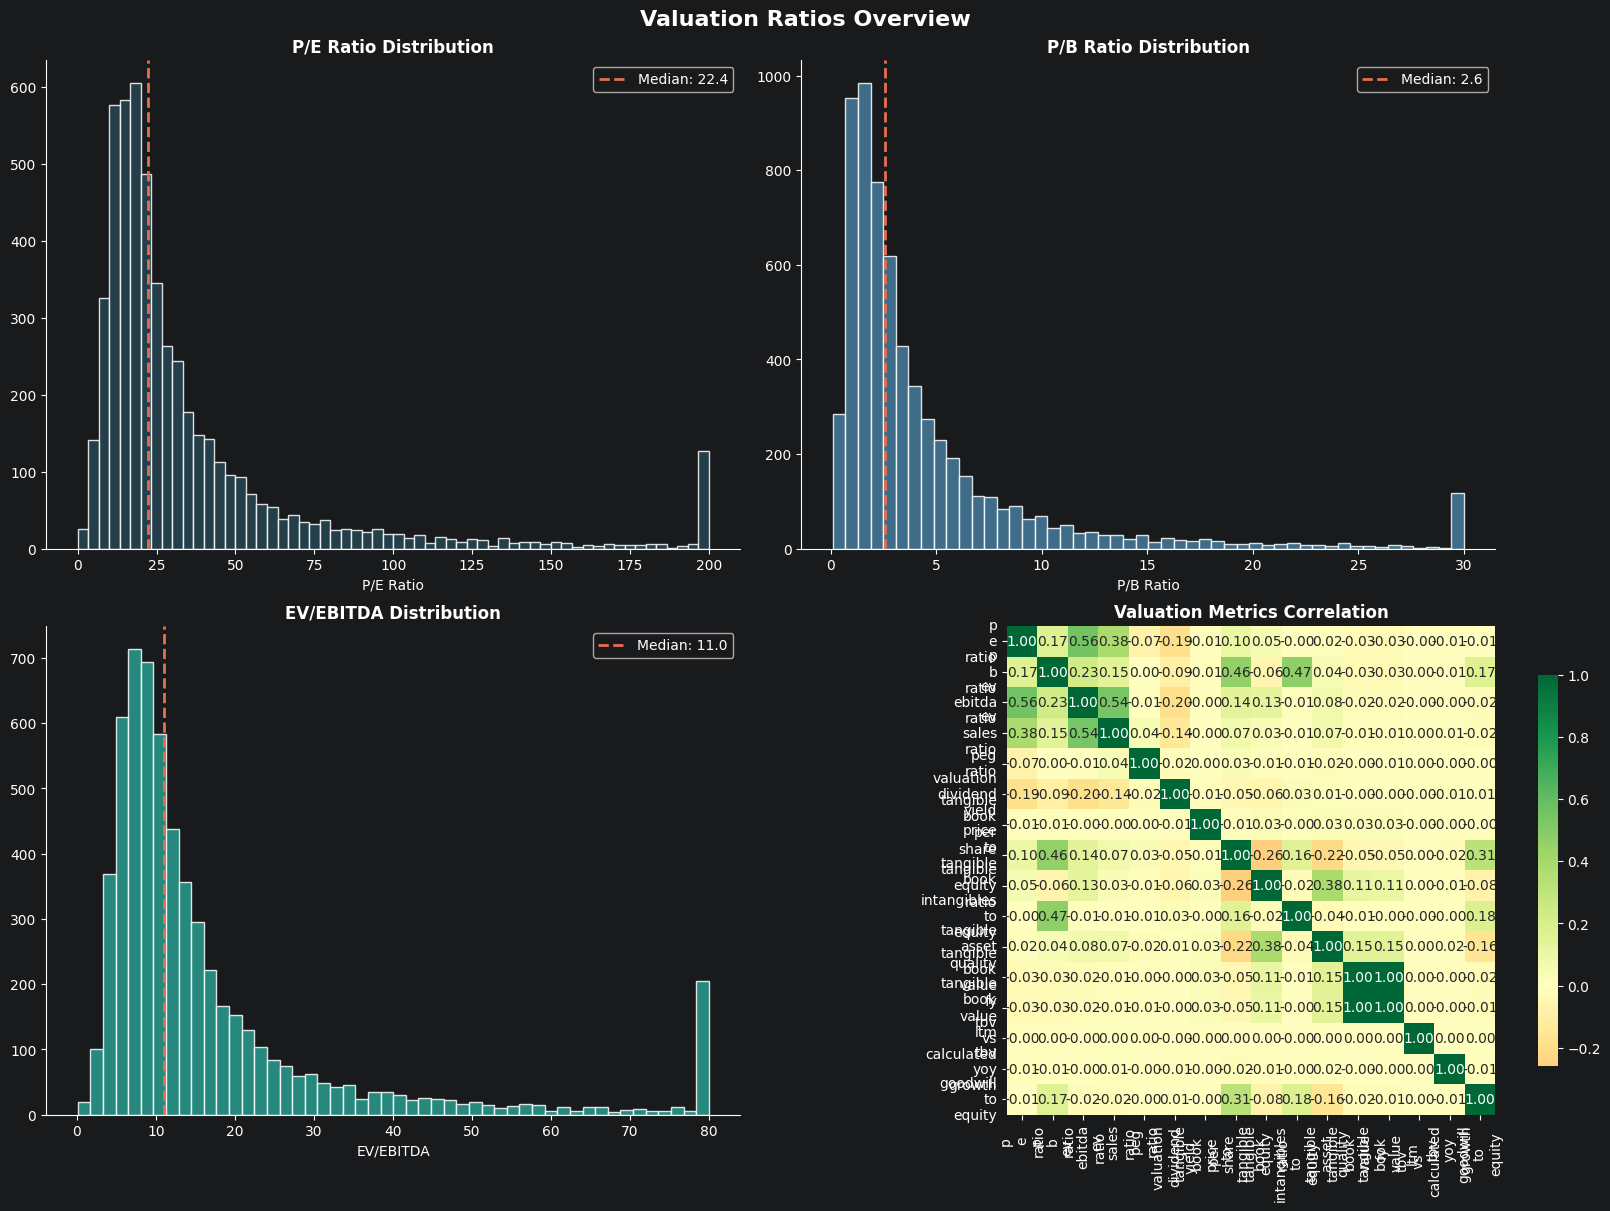

In [80]:
val_cols = [c for c in FEATURE_CATEGORIES.get("Valuation Ratios", []) if c in df.columns]
if len(val_cols) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
    fig.suptitle("Valuation Ratios Overview", fontsize=16, fontweight="bold")

    # P/E Distribution
    ax = axes[0, 0]
    pe_col = next((c for c in ["p_e_ratio"] if c in df.columns), None)
    if pe_col:
        pe_data = df[pe_col].dropna().clip(-50, 200)
        ax.hist(pe_data, bins=60, color=COLORS["primary"], alpha=0.85, edgecolor="white")
        ax.axvline(pe_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {pe_data.median():.1f}")
        ax.set_title("P/E Ratio Distribution", fontweight="bold")
        ax.set_xlabel("P/E Ratio")
        ax.legend()

    # P/B Distribution
    ax = axes[0, 1]
    pb_col = next((c for c in ["p_b_ratio"] if c in df.columns), None)
    if pb_col:
        pb_data = df[pb_col].dropna().clip(0, 30)
        ax.hist(pb_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
        ax.axvline(pb_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {pb_data.median():.1f}")
        ax.set_title("P/B Ratio Distribution", fontweight="bold")
        ax.set_xlabel("P/B Ratio")
        ax.legend()

    # EV/EBITDA Distribution
    ax = axes[1, 0]
    ev_col = next((c for c in ["ev_ebitda_ratio"] if c in df.columns), None)
    if ev_col:
        ev_data = df[ev_col].dropna().clip(-10, 80)
        ax.hist(ev_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
        ax.axvline(ev_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {ev_data.median():.1f}")
        ax.set_title("EV/EBITDA Distribution", fontweight="bold")
        ax.set_xlabel("EV/EBITDA")
        ax.legend()

    # Valuation correlation heatmap
    ax = axes[1, 1]
    val_data = df[val_cols].dropna(thresh=len(val_cols) // 2)
    if len(val_data) > 10:
        corr = val_data.corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                    ax=ax, cbar_kws={"shrink": 0.8}, square=True,
                    xticklabels=[c.replace("_", "\n") for c in corr.columns],
                    yticklabels=[c.replace("_", "\n") for c in corr.columns])
        ax.set_title("Valuation Metrics Correlation", fontweight="bold")

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 5. Profitability & Margins Analysis

C:\Users\markm\AppData\Local\Temp\ipykernel_20464\4253138167.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("_", "\n") for c in margin_cols], rotation=45, ha="right", fontsize=8)


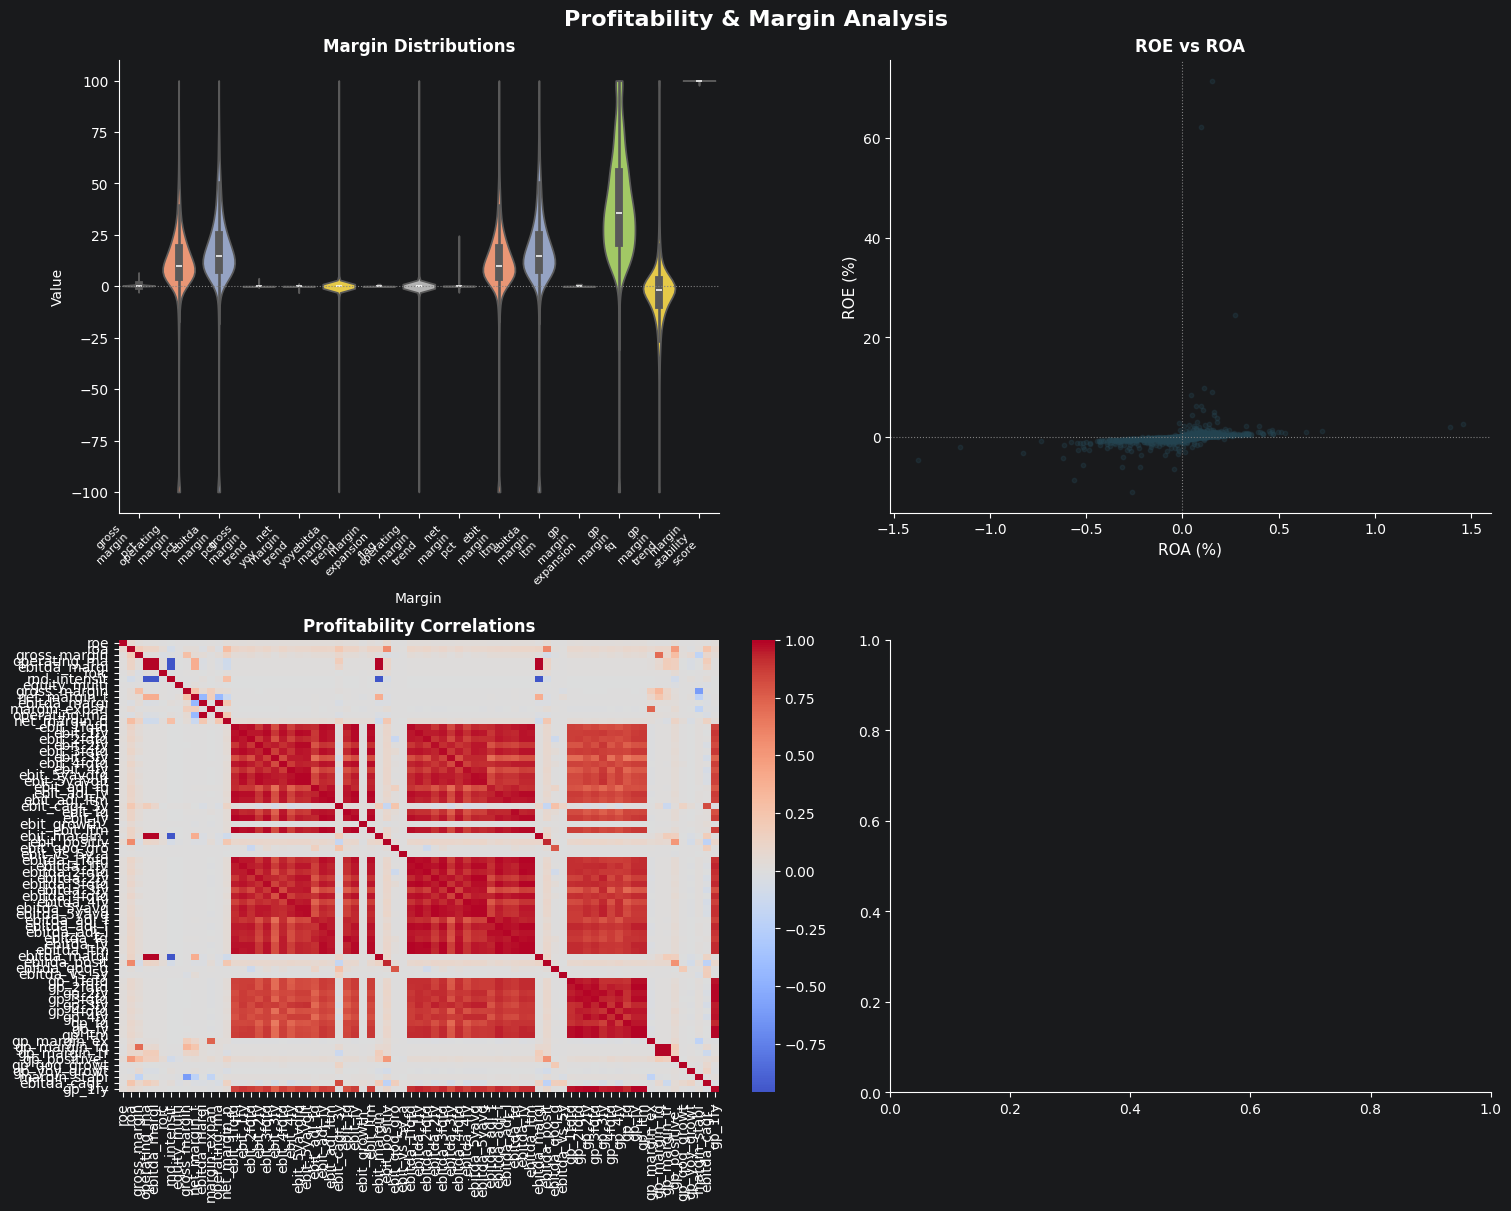

In [81]:
prof_cols = [c for c in FEATURE_CATEGORIES.get("Profitability", []) if c in df.columns]
margin_cols = [c for c in prof_cols if "margin" in c.lower()]
if margin_cols:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12), constrained_layout=True)
    fig.suptitle("Profitability & Margin Analysis", fontsize=16, fontweight="bold")

    # Margin distributions (violin)
    ax = axes[0, 0]
    margin_data = df[margin_cols].melt(var_name="Margin", value_name="Value")
    margin_data["Value"] = margin_data["Value"].clip(-100, 100)
    sns.violinplot(data=margin_data, x="Margin", y="Value", ax=ax, inner="box",
                   palette="Set2", cut=0)
    ax.set_xticklabels([c.replace("_", "\n") for c in margin_cols], rotation=45, ha="right", fontsize=8)
    ax.set_title("Margin Distributions", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)

    # ROE vs ROA scatter
    ax = axes[0, 1]
    roe_col = next((c for c in ["roe"] if c in df.columns), None)
    roa_col = next((c for c in ["roa"] if c in df.columns), None)
    if roe_col and roa_col:
        valid = df[[roe_col, roa_col]].dropna()
        valid = valid[(valid[roe_col].between(-100, 200)) & (valid[roa_col].between(-50, 50))]
        ax.scatter(valid[roa_col], valid[roe_col], alpha=0.3, s=10, c=COLORS["primary"])
        ax.set_xlabel("ROA (%)", fontsize=11)
        ax.set_ylabel("ROE (%)", fontsize=11)
        ax.set_title("ROE vs ROA", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    # Profitability correlation
    ax = axes[1, 0]
    if len(prof_cols) >= 3:
        prof_data = df[prof_cols].dropna(thresh=len(prof_cols) // 2)
        if len(prof_data) > 10:
            corr = prof_data.corr()
            sns.heatmap(corr, annot=False, fmt=".1f", cmap="coolwarm", center=0, ax=ax,
                        xticklabels=[c[:12] for c in corr.columns],
                        yticklabels=[c[:12] for c in corr.columns], square=False)
            ax.set_title("Profitability Correlations", fontweight="bold")

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 6. Momentum & Technical Analysis

C:\Users\markm\AppData\Local\Temp\ipykernel_20464\828036699.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("price_momentum_", "") for c in price_mom_cols],


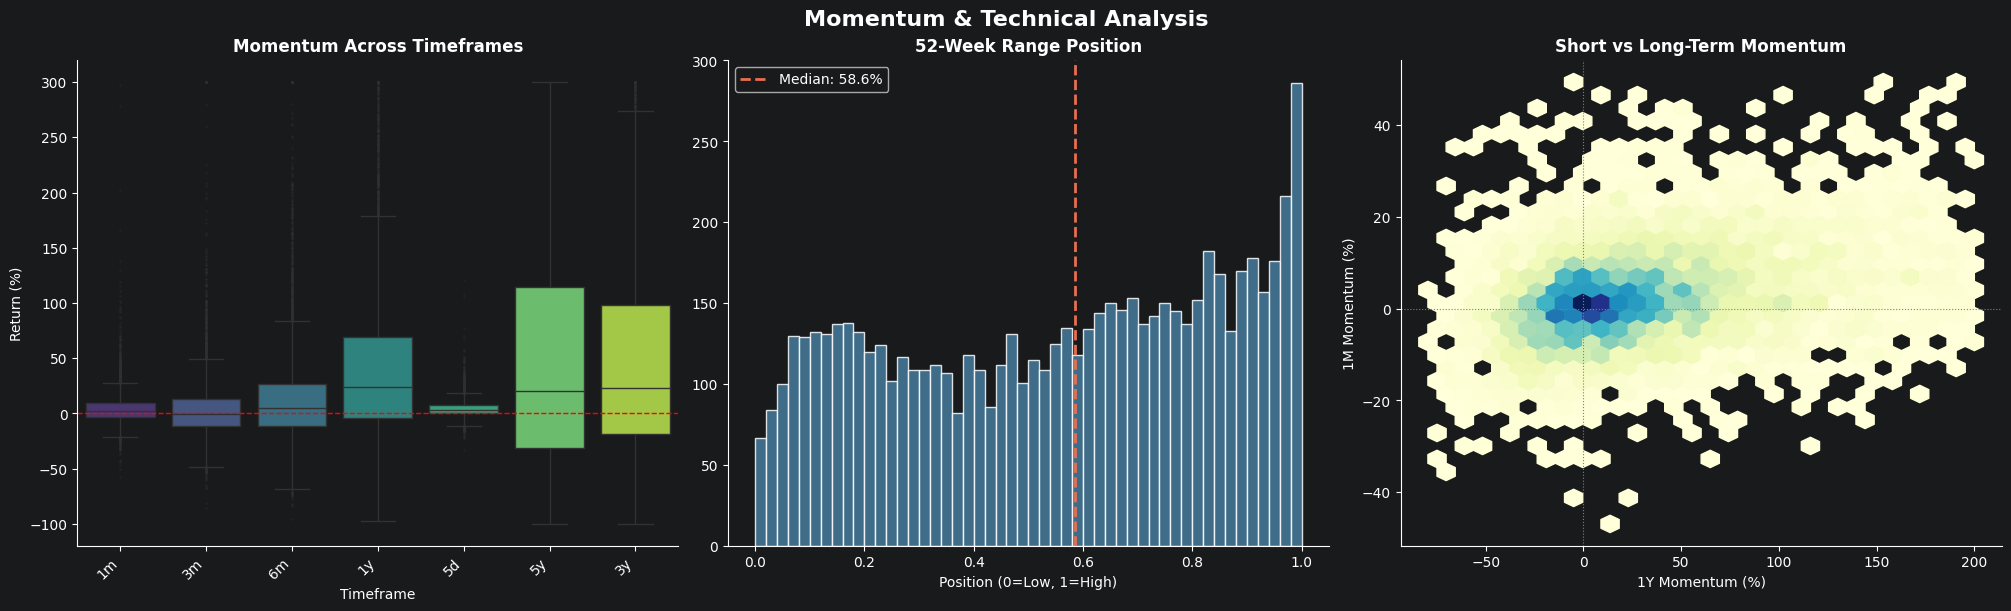

In [82]:
mom_cols = [c for c in FEATURE_CATEGORIES.get("Momentum & Technical", []) if c in df.columns]
price_mom_cols = [c for c in mom_cols if c.startswith("price_momentum")]
if price_mom_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    fig.suptitle("Momentum & Technical Analysis", fontsize=16, fontweight="bold")

    # Momentum ribbon (box plots across timeframes)
    ax = axes[0]
    mom_data = df[price_mom_cols].melt(var_name="Timeframe", value_name="Return")
    mom_data["Return"] = mom_data["Return"].clip(-100, 300)
    sns.boxplot(data=mom_data, x="Timeframe", y="Return", ax=ax, palette="viridis",
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_xticklabels([c.replace("price_momentum_", "") for c in price_mom_cols],
                       rotation=45, ha="right")
    ax.axhline(0, color="red", linestyle="--", lw=1)
    ax.set_title("Momentum Across Timeframes", fontweight="bold")
    ax.set_ylabel("Return (%)")

    # 52-week range position histogram
    ax = axes[1]
    range_col = next((c for c in ["range_52w_position"] if c in df.columns), None)
    if range_col:
        range_data = df[range_col].dropna()
        ax.hist(range_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
        ax.axvline(range_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {range_data.median():.1%}")
        ax.set_title("52-Week Range Position", fontweight="bold")
        ax.set_xlabel("Position (0=Low, 1=High)")
        ax.legend()

    # Short vs long-term momentum scatter
    ax = axes[2]
    short_col = next((c for c in ["price_momentum_1m"] if c in df.columns), None)
    long_col = next((c for c in ["price_momentum_1y"] if c in df.columns), None)
    if short_col and long_col:
        valid = df[[short_col, long_col]].dropna()
        valid = valid[valid[short_col].between(-50, 50) & valid[long_col].between(-80, 200)]
        ax.hexbin(valid[long_col], valid[short_col], gridsize=30, cmap="YlGnBu", mincnt=1)
        ax.set_xlabel("1Y Momentum (%)")
        ax.set_ylabel("1M Momentum (%)")
        ax.set_title("Short vs Long-Term Momentum", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 7. Earnings Quality & EPS Trajectory

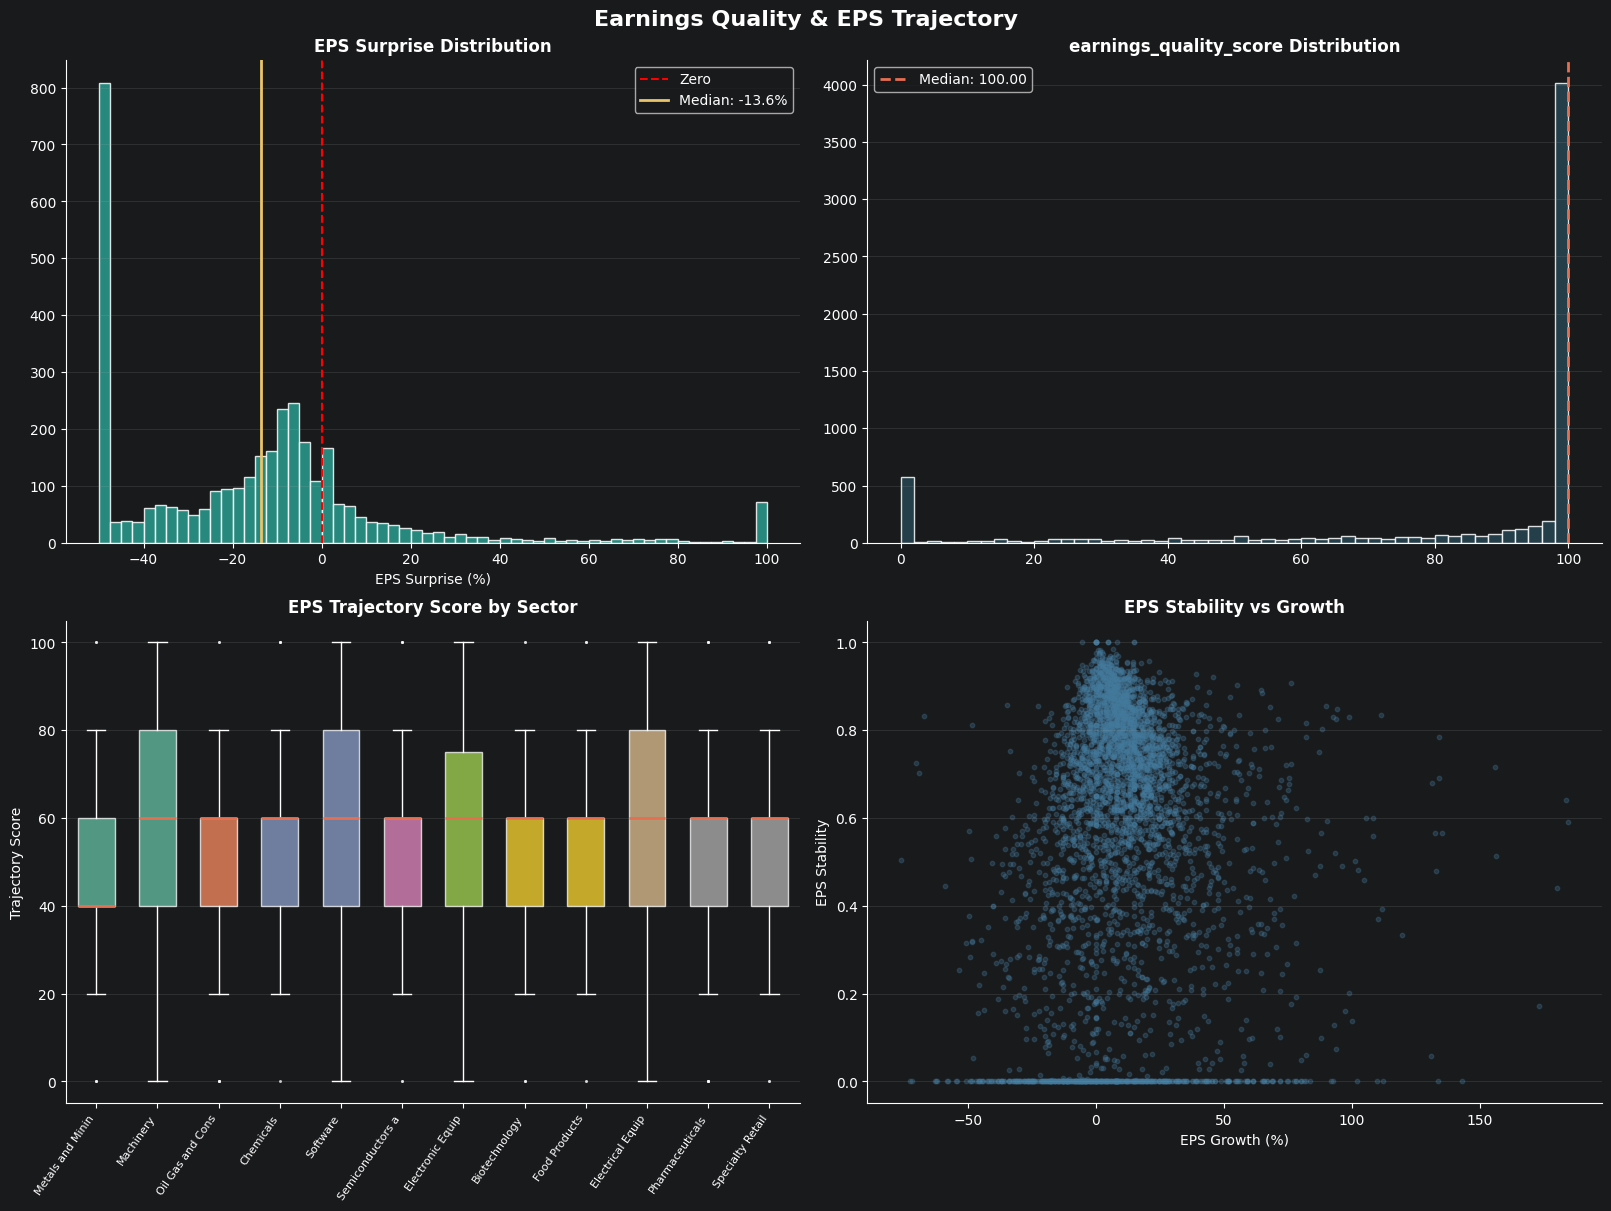

In [83]:
eq_cols = [c for c in FEATURE_CATEGORIES.get("Earnings Quality", []) if c in df.columns]
eps_cols = [c for c in FEATURE_CATEGORIES.get("EPS Trajectory", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Earnings Quality & EPS Trajectory", fontsize=16, fontweight="bold")

# EPS surprise distribution
ax = axes[0, 0]
surprise_col = next((c for c in ["eps_surprise_pct"] if c in df.columns), None)
if surprise_col:
    surprise_data = df[surprise_col].dropna().clip(-50, 100)
    ax.hist(surprise_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero")
    ax.axvline(surprise_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {surprise_data.median():.1f}%")
    ax.set_title("EPS Surprise Distribution", fontweight="bold")
    ax.set_xlabel("EPS Surprise (%)")
    ax.legend()

# Earnings quality score distribution
ax = axes[0, 1]
eq_score = next((c for c in ["earnings_quality_score", "earnings_quality_composite"] if c in df.columns), None)
if eq_score:
    score_data = df[eq_score].dropna()
    ax.hist(score_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(score_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {score_data.median():.2f}")
    ax.set_title(f"{eq_score} Distribution", fontweight="bold")
    ax.legend()

# EPS trajectory score by sector
ax = axes[1, 0]
traj_col = next((c for c in ["eps_trajectory_score"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if traj_col and sector_col:
    sectors = df[sector_col].value_counts().head(12).index
    sector_data = [df.loc[df[sector_col] == s, traj_col].dropna().values for s in sectors]
    bp = ax.boxplot(sector_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.set_title("EPS Trajectory Score by Sector", fontweight="bold")
    ax.set_ylabel("Trajectory Score")

# EPS stability vs growth scatter
ax = axes[1, 1]
stab_col = next((c for c in ["eps_stability"] if c in df.columns), None)
growth_col = next((c for c in ["eps_cagr_5y", "eps_yoy_growth"] if c in df.columns), None)
if stab_col and growth_col:
    valid = df[[stab_col, growth_col]].dropna()
    valid = valid[valid[growth_col].between(-100, 200)]
    ax.scatter(valid[growth_col], valid[stab_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.set_xlabel("EPS Growth (%)")
    ax.set_ylabel("EPS Stability")
    ax.set_title("EPS Stability vs Growth", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 8. Growth Metrics Analysis

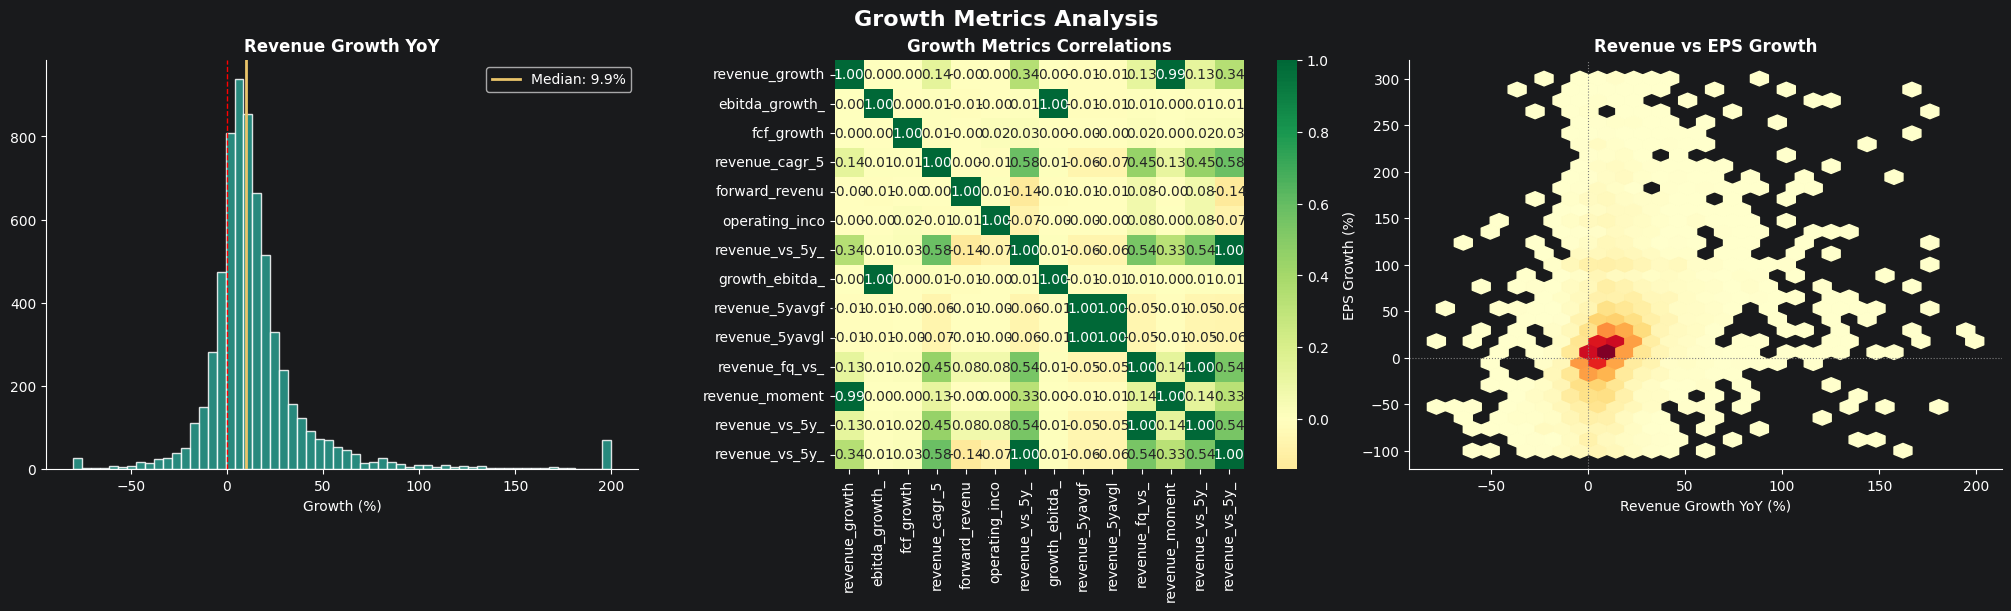

In [84]:
growth_cols = [c for c in FEATURE_CATEGORIES.get("Growth Metrics", []) if c in df.columns]
if growth_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    fig.suptitle("Growth Metrics Analysis", fontsize=16, fontweight="bold")

    # Revenue growth distribution
    ax = axes[0]
    rev_col = next((c for c in ["revenue_growth_yoy"] if c in df.columns), None)
    if rev_col:
        rev_data = df[rev_col].dropna().clip(-80, 200)
        ax.hist(rev_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
        ax.axvline(0, color="red", linestyle="--", lw=1)
        ax.axvline(rev_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
                   label=f"Median: {rev_data.median():.1f}%")
        ax.set_title("Revenue Growth YoY", fontweight="bold")
        ax.set_xlabel("Growth (%)")
        ax.legend()

    # Growth correlation heatmap
    ax = axes[1]
    g_data = df[growth_cols].dropna(thresh=len(growth_cols) // 2)
    if len(g_data) > 10:
        corr = g_data.corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax,
                    xticklabels=[c[:14] for c in corr.columns],
                    yticklabels=[c[:14] for c in corr.columns], square=True)
        ax.set_title("Growth Metrics Correlations", fontweight="bold")

    # Revenue vs EPS growth scatter
    ax = axes[2]
    eps_g = next((c for c in ["eps_yoy_growth", "eps_cagr_5y"] if c in df.columns), None)
    if rev_col and eps_g:
        valid = df[[rev_col, eps_g]].dropna()
        valid = valid[valid[rev_col].between(-80, 200) & valid[eps_g].between(-100, 300)]
        ax.hexbin(valid[rev_col], valid[eps_g], gridsize=30, cmap="YlOrRd", mincnt=1)
        ax.set_xlabel("Revenue Growth YoY (%)")
        ax.set_ylabel("EPS Growth (%)")
        ax.set_title("Revenue vs EPS Growth", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 9. Quality & Risk Assessment

C:\Users\markm\AppData\Local\Temp\ipykernel_20464\2282882155.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


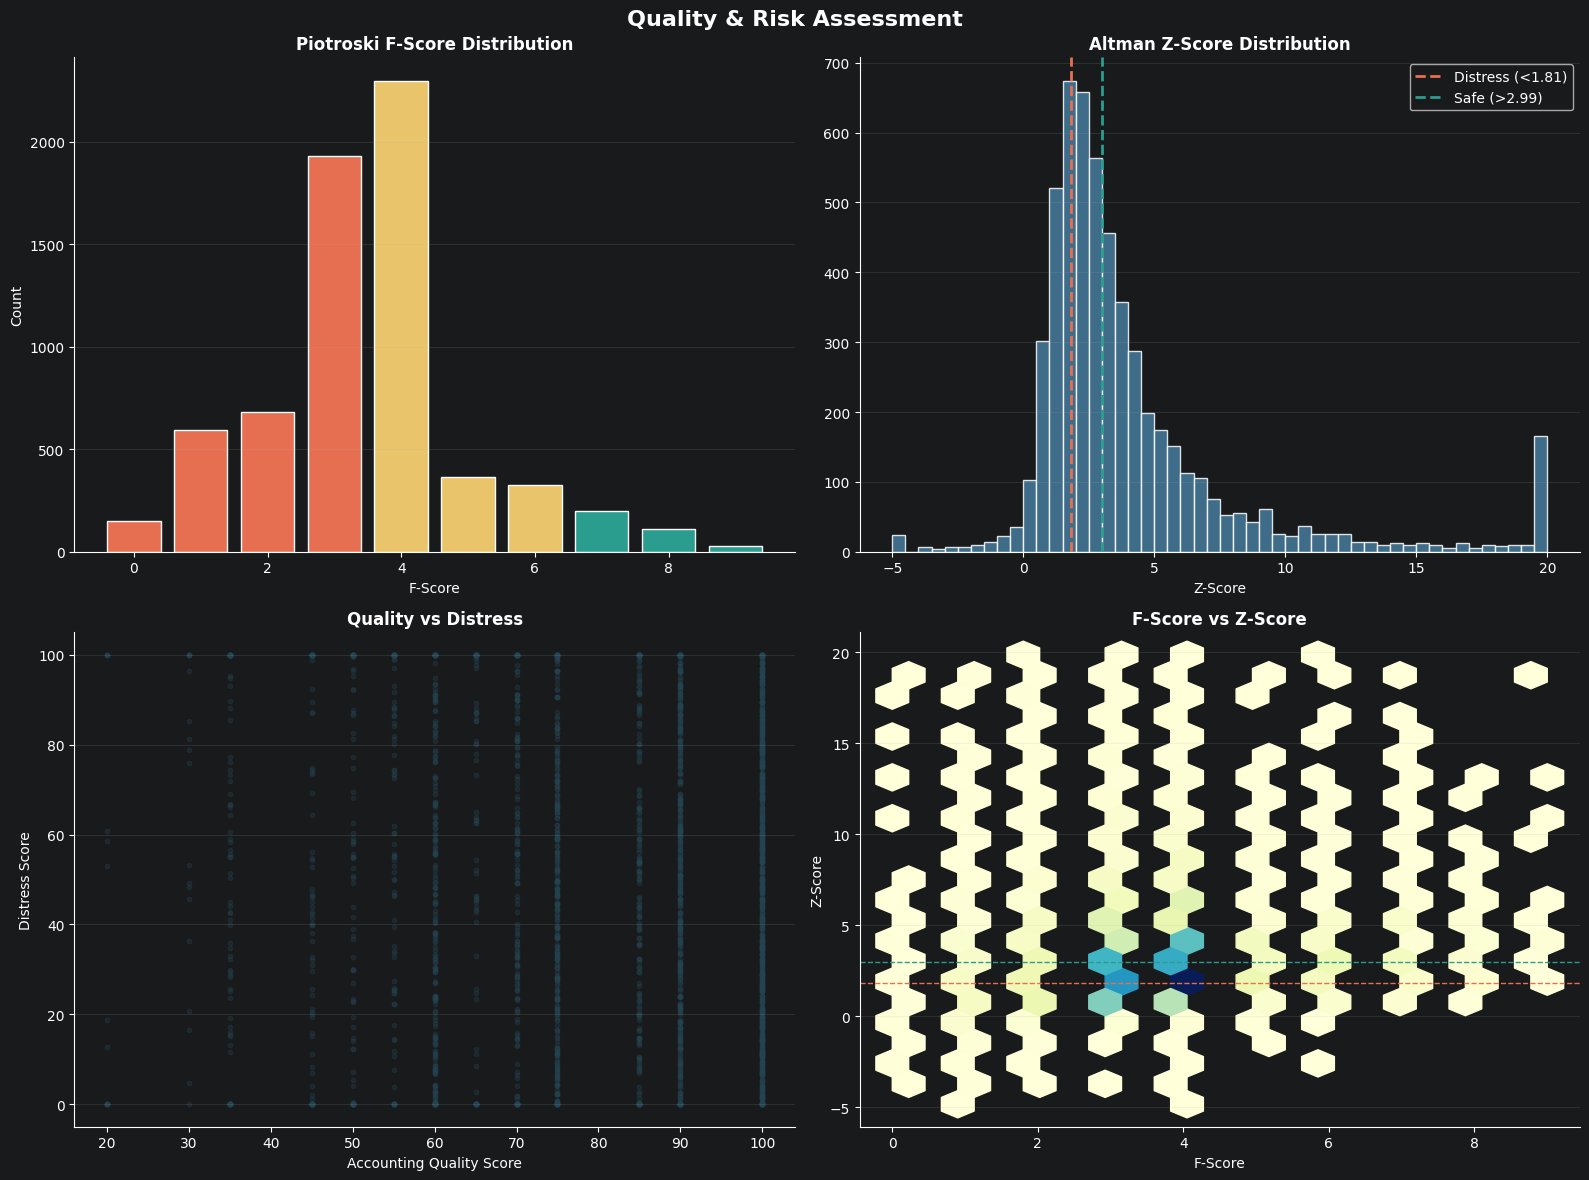

In [85]:
qr_cols = [c for c in FEATURE_CATEGORIES.get("Quality & Risk", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Quality & Risk Assessment", fontsize=16, fontweight="bold")

# Piotroski F-Score distribution
ax = axes[0, 0]
fscore_col = next((c for c in ["piotroski_f_score"] if c in df.columns), None)
if fscore_col:
    fscore_data = df[fscore_col].dropna()
    counts = fscore_data.value_counts().sort_index()
    bar_colors = [COLORS["danger"] if v <= 3 else COLORS["accent"] if v <= 6
    else COLORS["secondary"] for v in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
    ax.set_title("Piotroski F-Score Distribution", fontweight="bold")
    ax.set_xlabel("F-Score")
    ax.set_ylabel("Count")

# Altman Z-Score distribution
ax = axes[0, 1]
zscore_col = next((c for c in ["altman_z_score", "altman_z_score_fy"] if c in df.columns), None)
if zscore_col:
    zscore_data = df[zscore_col].dropna().clip(-5, 20)
    ax.hist(zscore_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(1.81, color=COLORS["danger"], linestyle="--", lw=2, label="Distress (<1.81)")
    ax.axvline(2.99, color=COLORS["secondary"], linestyle="--", lw=2, label="Safe (>2.99)")
    ax.set_title("Altman Z-Score Distribution", fontweight="bold")
    ax.set_xlabel("Z-Score")
    ax.legend()

# Quality score vs Risk scatter
ax = axes[1, 0]
aq_col = next((c for c in ["accounting_quality_score"] if c in df.columns), None)
distress_col = next((c for c in ["combined_distress_score"] if c in df.columns), None)
if aq_col and distress_col:
    valid = df[[aq_col, distress_col]].dropna()
    ax.scatter(valid[aq_col], valid[distress_col], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("Accounting Quality Score")
    ax.set_ylabel("Distress Score")
    ax.set_title("Quality vs Distress", fontweight="bold")

# F-Score vs Z-Score joint distribution
ax = axes[1, 1]
if fscore_col and zscore_col:
    valid = df[[fscore_col, zscore_col]].dropna()
    valid = valid[valid[zscore_col].between(-5, 20)]
    ax.hexbin(valid[fscore_col], valid[zscore_col], gridsize=20, cmap="YlGnBu", mincnt=1)
    ax.set_xlabel("F-Score")
    ax.set_ylabel("Z-Score")
    ax.set_title("F-Score vs Z-Score", fontweight="bold")
    ax.axhline(1.81, color=COLORS["danger"], linestyle="--", lw=1)
    ax.axhline(2.99, color=COLORS["secondary"], linestyle="--", lw=1)

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Leverage & Liquidity Analysis

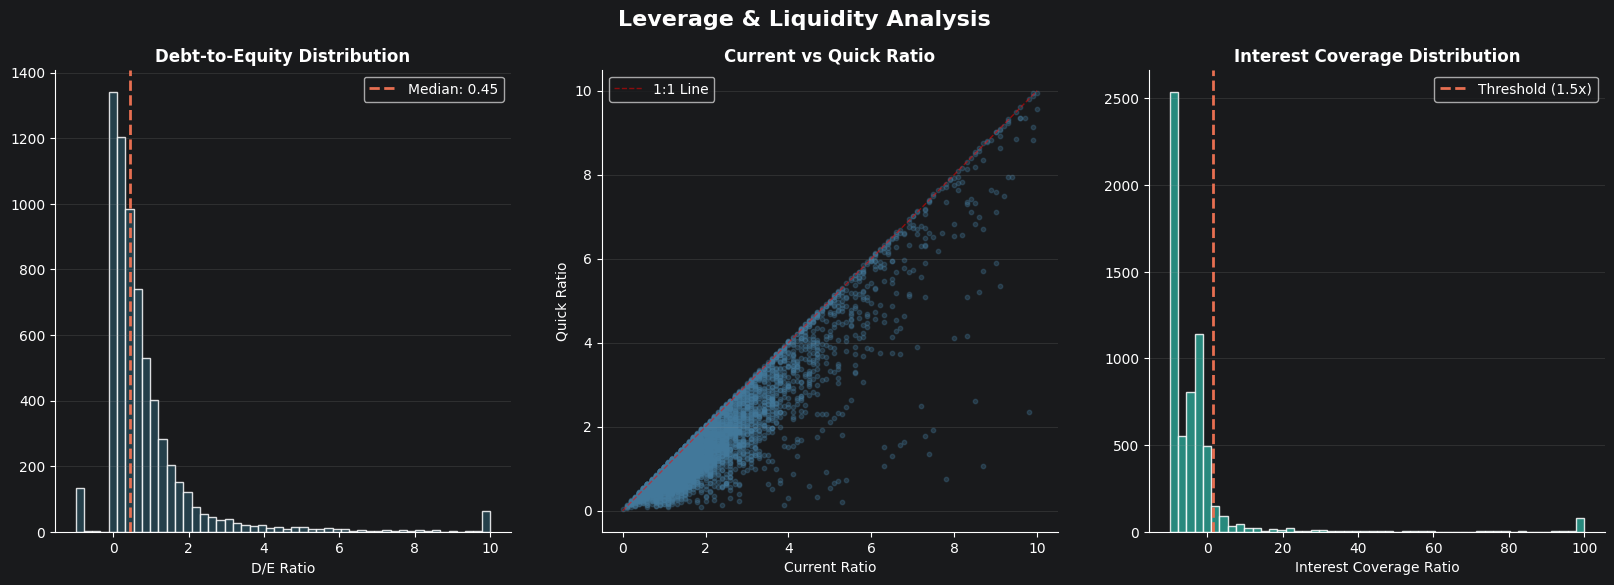

In [86]:
lev_cols = [c for c in FEATURE_CATEGORIES.get("Leverage & Liquidity", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Leverage & Liquidity Analysis", fontsize=16, fontweight="bold")

# Debt-to-Equity distribution
ax = axes[0]
dte_col = next((c for c in ["debt_to_equity"] if c in df.columns), None)
if dte_col:
    dte_data = df[dte_col].dropna().clip(-1, 10)
    ax.hist(dte_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(dte_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {dte_data.median():.2f}")
    ax.set_title("Debt-to-Equity Distribution", fontweight="bold")
    ax.set_xlabel("D/E Ratio")
    ax.legend()

# Current Ratio vs Quick Ratio
ax = axes[1]
cr_col = next((c for c in ["current_ratio"] if c in df.columns), None)
qr_col = next((c for c in ["quick_ratio"] if c in df.columns), None)
if cr_col and qr_col:
    valid = df[[cr_col, qr_col]].dropna()
    valid = valid[(valid[cr_col].between(0, 10)) & (valid[qr_col].between(0, 10))]
    ax.scatter(valid[cr_col], valid[qr_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.plot([0, 10], [0, 10], "r--", lw=1, alpha=0.5, label="1:1 Line")
    ax.set_xlabel("Current Ratio")
    ax.set_ylabel("Quick Ratio")
    ax.set_title("Current vs Quick Ratio", fontweight="bold")
    ax.legend()

# Interest coverage distribution
ax = axes[2]
ic_col = next((c for c in ["interest_coverage"] if c in df.columns), None)
if ic_col:
    ic_data = df[ic_col].dropna().clip(-10, 100)
    ax.hist(ic_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(1.5, color=COLORS["danger"], linestyle="--", lw=2, label="Threshold (1.5x)")
    ax.set_title("Interest Coverage Distribution", fontweight="bold")
    ax.set_xlabel("Interest Coverage Ratio")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 11. Analyst Sentiment & Price Targets

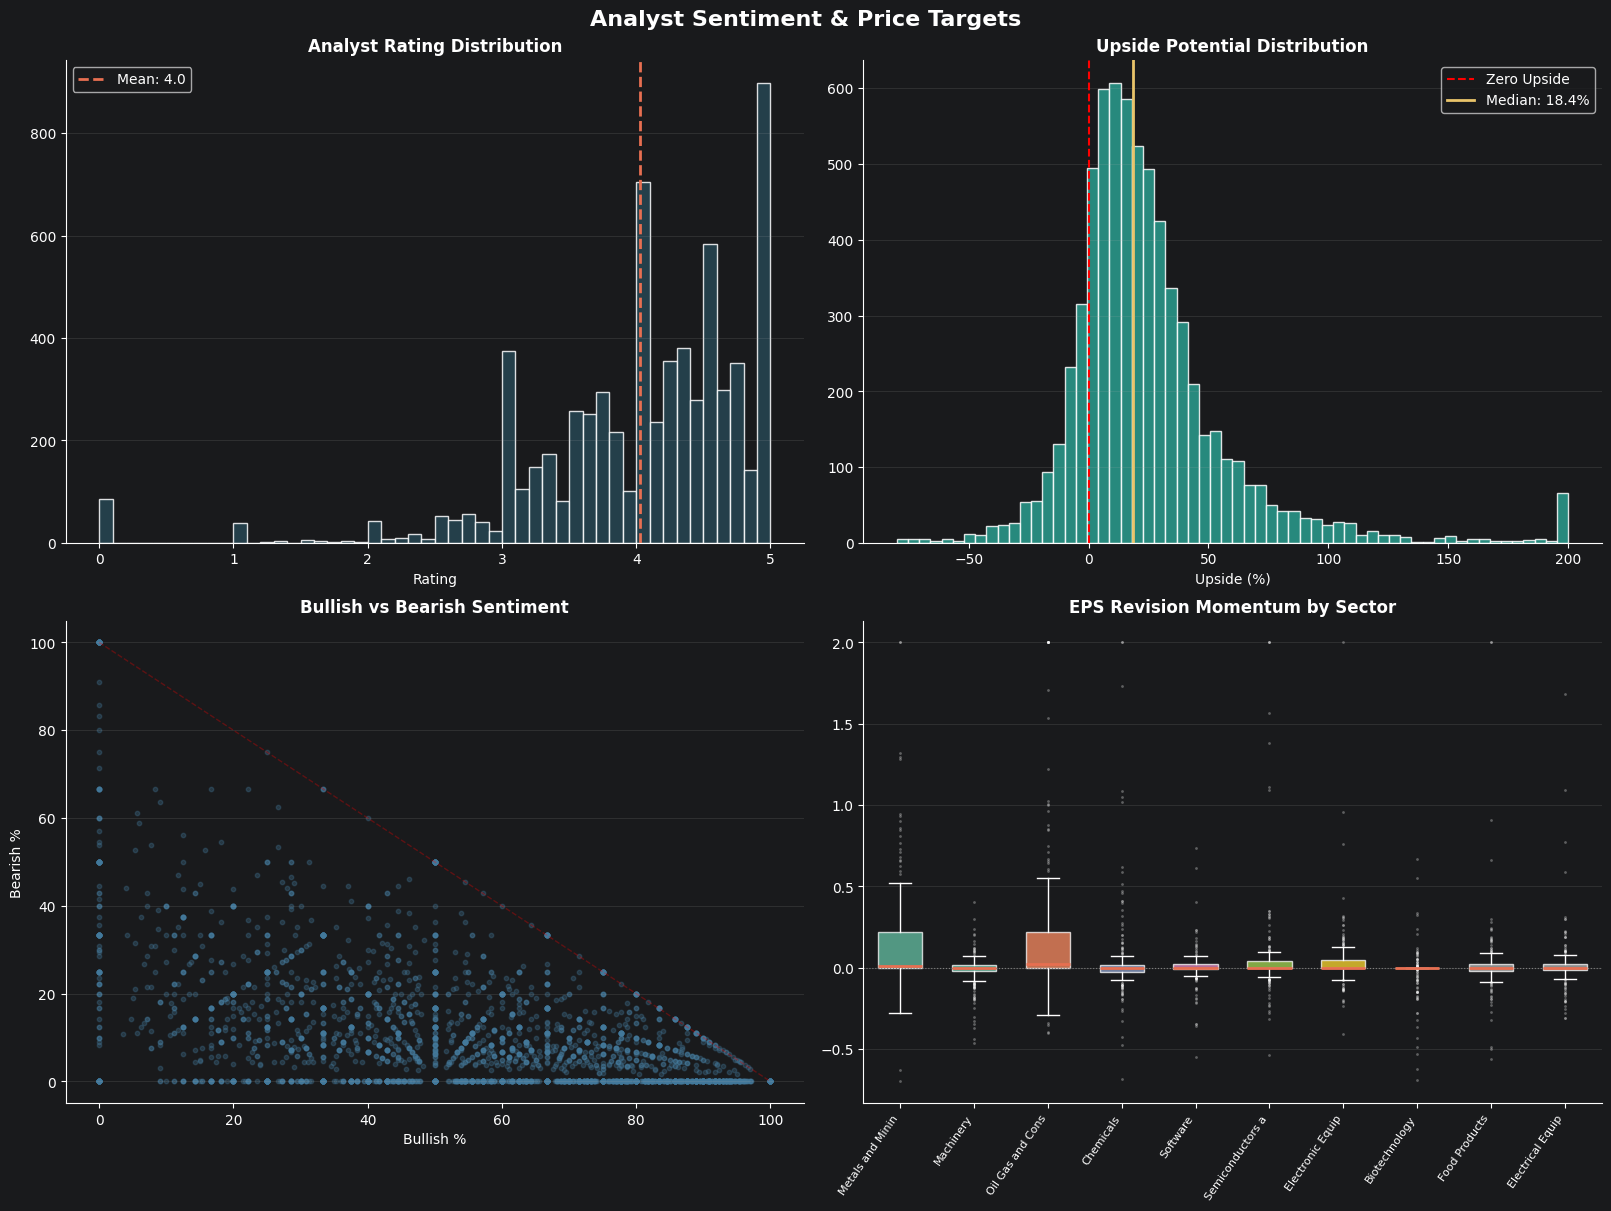

In [87]:
sent_cols = [c for c in FEATURE_CATEGORIES.get("Analyst Sentiment", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Analyst Sentiment & Price Targets", fontsize=16, fontweight="bold")

# Analyst rating distribution
ax = axes[0, 0]
rating_col = next((c for c in ["analyst_rating"] if c in df.columns), None)
if rating_col:
    rating_data = df[rating_col].dropna()
    ax.hist(rating_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(rating_data.mean(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Mean: {rating_data.mean():.1f}")
    ax.set_title("Analyst Rating Distribution", fontweight="bold")
    ax.set_xlabel("Rating")
    ax.legend()

# Upside potential distribution
ax = axes[0, 1]
upside_col = next((c for c in ["upside_potential"] if c in df.columns), None)
if upside_col:
    upside_data = df[upside_col].dropna().clip(-80, 200)
    ax.hist(upside_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero Upside")
    ax.axvline(upside_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {upside_data.median():.1f}%")
    ax.set_title("Upside Potential Distribution", fontweight="bold")
    ax.set_xlabel("Upside (%)")
    ax.legend()

# Bullish vs Bearish sentiment
ax = axes[1, 0]
bull_col = next((c for c in ["analyst_bullish_pct"] if c in df.columns), None)
bear_col = next((c for c in ["analyst_bearish_pct"] if c in df.columns), None)
if bull_col and bear_col:
    valid = df[[bull_col, bear_col]].dropna()
    ax.scatter(valid[bull_col], valid[bear_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.set_xlabel("Bullish %")
    ax.set_ylabel("Bearish %")
    ax.set_title("Bullish vs Bearish Sentiment", fontweight="bold")
    ax.plot([0, 100], [100, 0], "r--", lw=1, alpha=0.3)

# EPS revision momentum by sector
ax = axes[1, 1]
rev_mom_col = next((c for c in ["eps_revision_momentum"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if rev_mom_col and sector_col:
    sectors = df[sector_col].value_counts().head(10).index
    rev_data = [df.loc[df[sector_col] == s, rev_mom_col].dropna().clip(-2, 2).values for s in sectors]
    bp = ax.boxplot(rev_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.set_title("EPS Revision Momentum by Sector", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 12. Cash Flow Analysis

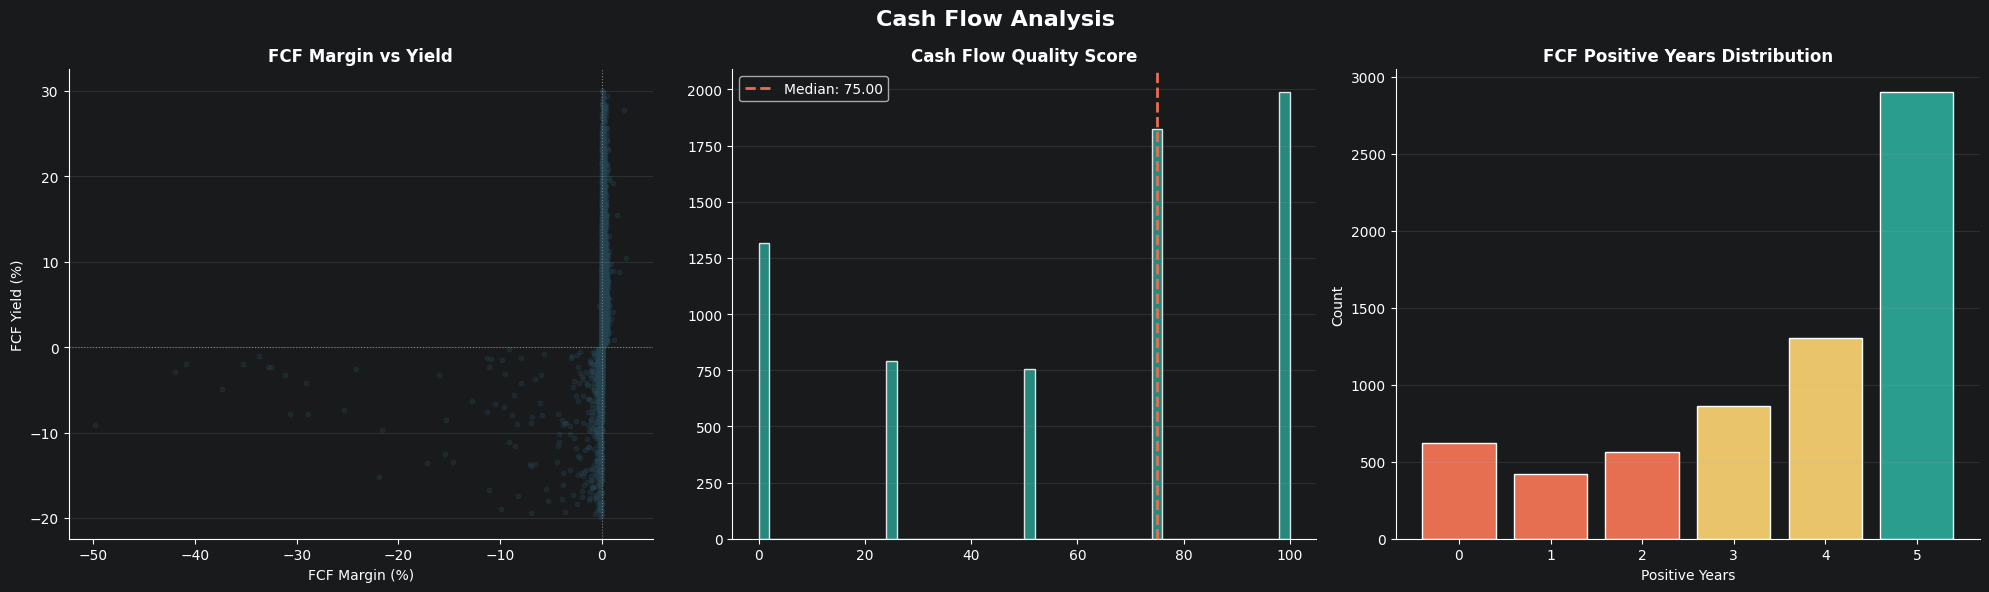

In [88]:
cf_cols = [c for c in FEATURE_CATEGORIES.get("Cash Flow", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Cash Flow Analysis", fontsize=16, fontweight="bold")

# FCF margin vs FCF yield scatter
ax = axes[0]
fcf_m = next((c for c in ["fcf_margin"] if c in df.columns), None)
fcf_y = next((c for c in ["fcf_yield"] if c in df.columns), None)
if fcf_m and fcf_y:
    valid = df[[fcf_m, fcf_y]].dropna()
    valid = valid[valid[fcf_m].between(-50, 60) & valid[fcf_y].between(-20, 30)]
    ax.scatter(valid[fcf_m], valid[fcf_y], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("FCF Margin (%)")
    ax.set_ylabel("FCF Yield (%)")
    ax.set_title("FCF Margin vs Yield", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.axvline(0, color="grey", linestyle=":", lw=0.8)

# Cash flow quality score
ax = axes[1]
cfq_col = next((c for c in ["cash_flow_quality_score"] if c in df.columns), None)
if cfq_col:
    cfq_data = df[cfq_col].dropna()
    ax.hist(cfq_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(cfq_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {cfq_data.median():.2f}")
    ax.set_title("Cash Flow Quality Score", fontweight="bold")
    ax.legend()

# FCF positive years distribution
ax = axes[2]
fcf_pos = next((c for c in ["fcf_positive_years"] if c in df.columns), None)
if fcf_pos:
    pos_data = df[fcf_pos].dropna()
    counts = pos_data.value_counts().sort_index()
    bar_colors = [COLORS["danger"] if v <= 2 else COLORS["accent"] if v <= 4
    else COLORS["secondary"] for v in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
    ax.set_title("FCF Positive Years Distribution", fontweight="bold")
    ax.set_xlabel("Positive Years")
    ax.set_ylabel("Count")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Dividend Reliability Analysis

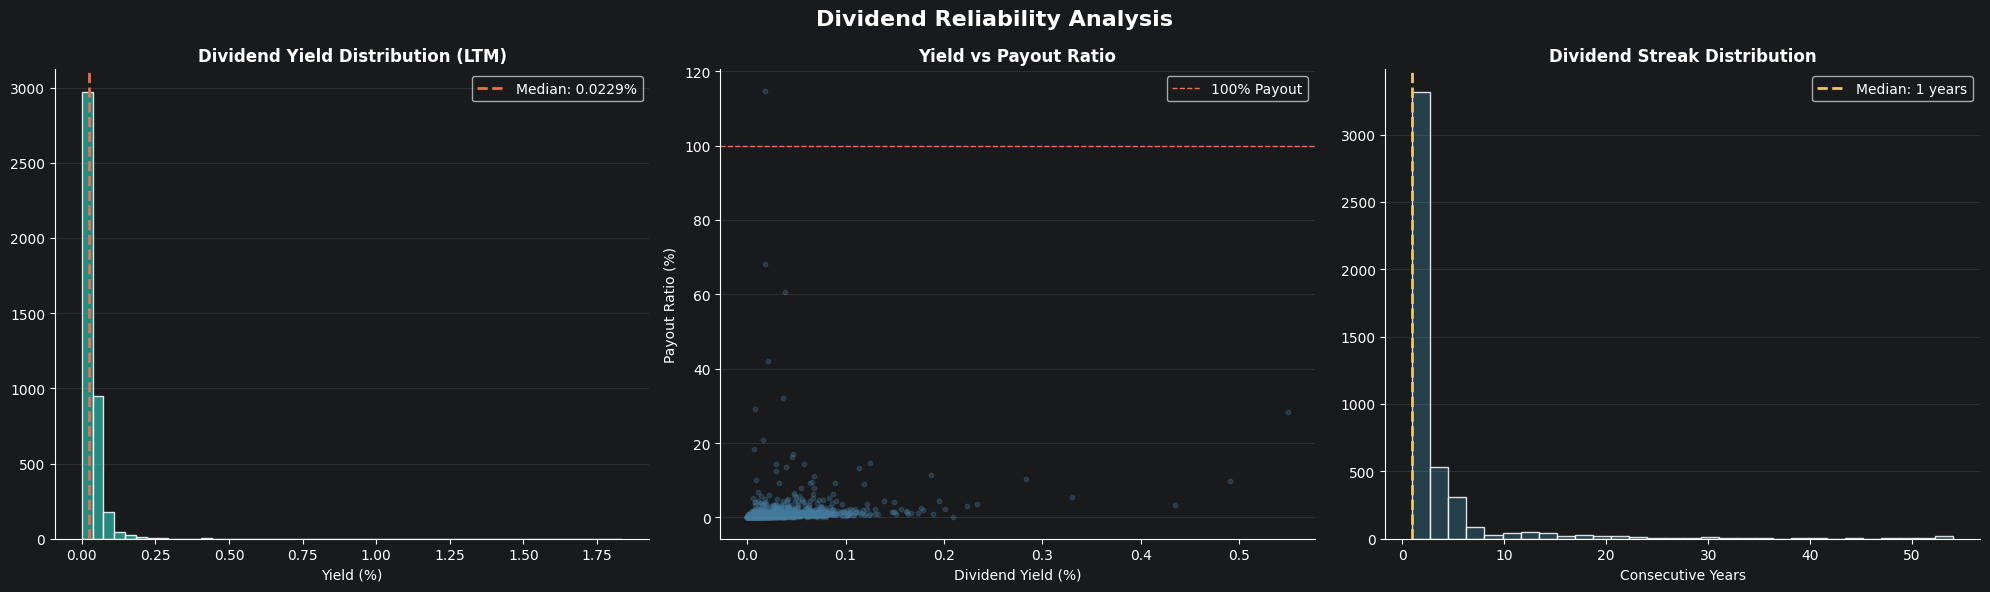

In [89]:
div_cols = [c for c in FEATURE_CATEGORIES.get("Dividend Reliability", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Dividend Reliability Analysis", fontsize=16, fontweight="bold")

# Dividend yield distribution
ax = axes[0]
dy_col = next((c for c in ["dividend_yield_ltm"] if c in df.columns), None)
if dy_col:
    dy_data = df[dy_col].dropna()
    ax.hist(dy_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(dy_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {dy_data.median():.4f}%")
    ax.set_title("Dividend Yield Distribution (LTM)", fontweight="bold")
    ax.set_xlabel("Yield (%)")
    ax.legend()

# Dividend yield vs payout ratio
ax = axes[1]
payout_col = next((c for c in ["dividend_payout_ratio"] if c in df.columns), None)
if dy_col and payout_col:
    valid = df[[dy_col, payout_col]].dropna()
    valid = valid[(valid[dy_col] > 0) & valid[payout_col].between(0, 200)]
    ax.scatter(valid[dy_col], valid[payout_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.axhline(100, color=COLORS["danger"], linestyle="--", lw=1, label="100% Payout")
    ax.set_xlabel("Dividend Yield (%)")
    ax.set_ylabel("Payout Ratio (%)")
    ax.set_title("Yield vs Payout Ratio", fontweight="bold")
    ax.legend()

# Dividend streak distribution
ax = axes[2]
streak_col = next((c for c in ["dividend_streak"] if c in df.columns), None)
if streak_col:
    streak_data = df[streak_col].dropna()
    streak_data = streak_data[streak_data > 0]
    ax.hist(streak_data, bins=30, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(streak_data.median(), color=COLORS["accent"], linestyle="--", lw=2,
               label=f"Median: {streak_data.median():.0f} years")
    ax.set_title("Dividend Streak Distribution", fontweight="bold")
    ax.set_xlabel("Consecutive Years")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 14. Volatility Surface Analysis (Enhancement 2+3)

C:\Users\markm\AppData\Local\Temp\ipykernel_20464\1481445140.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("volatility_", "") for c in vol_term_cols])


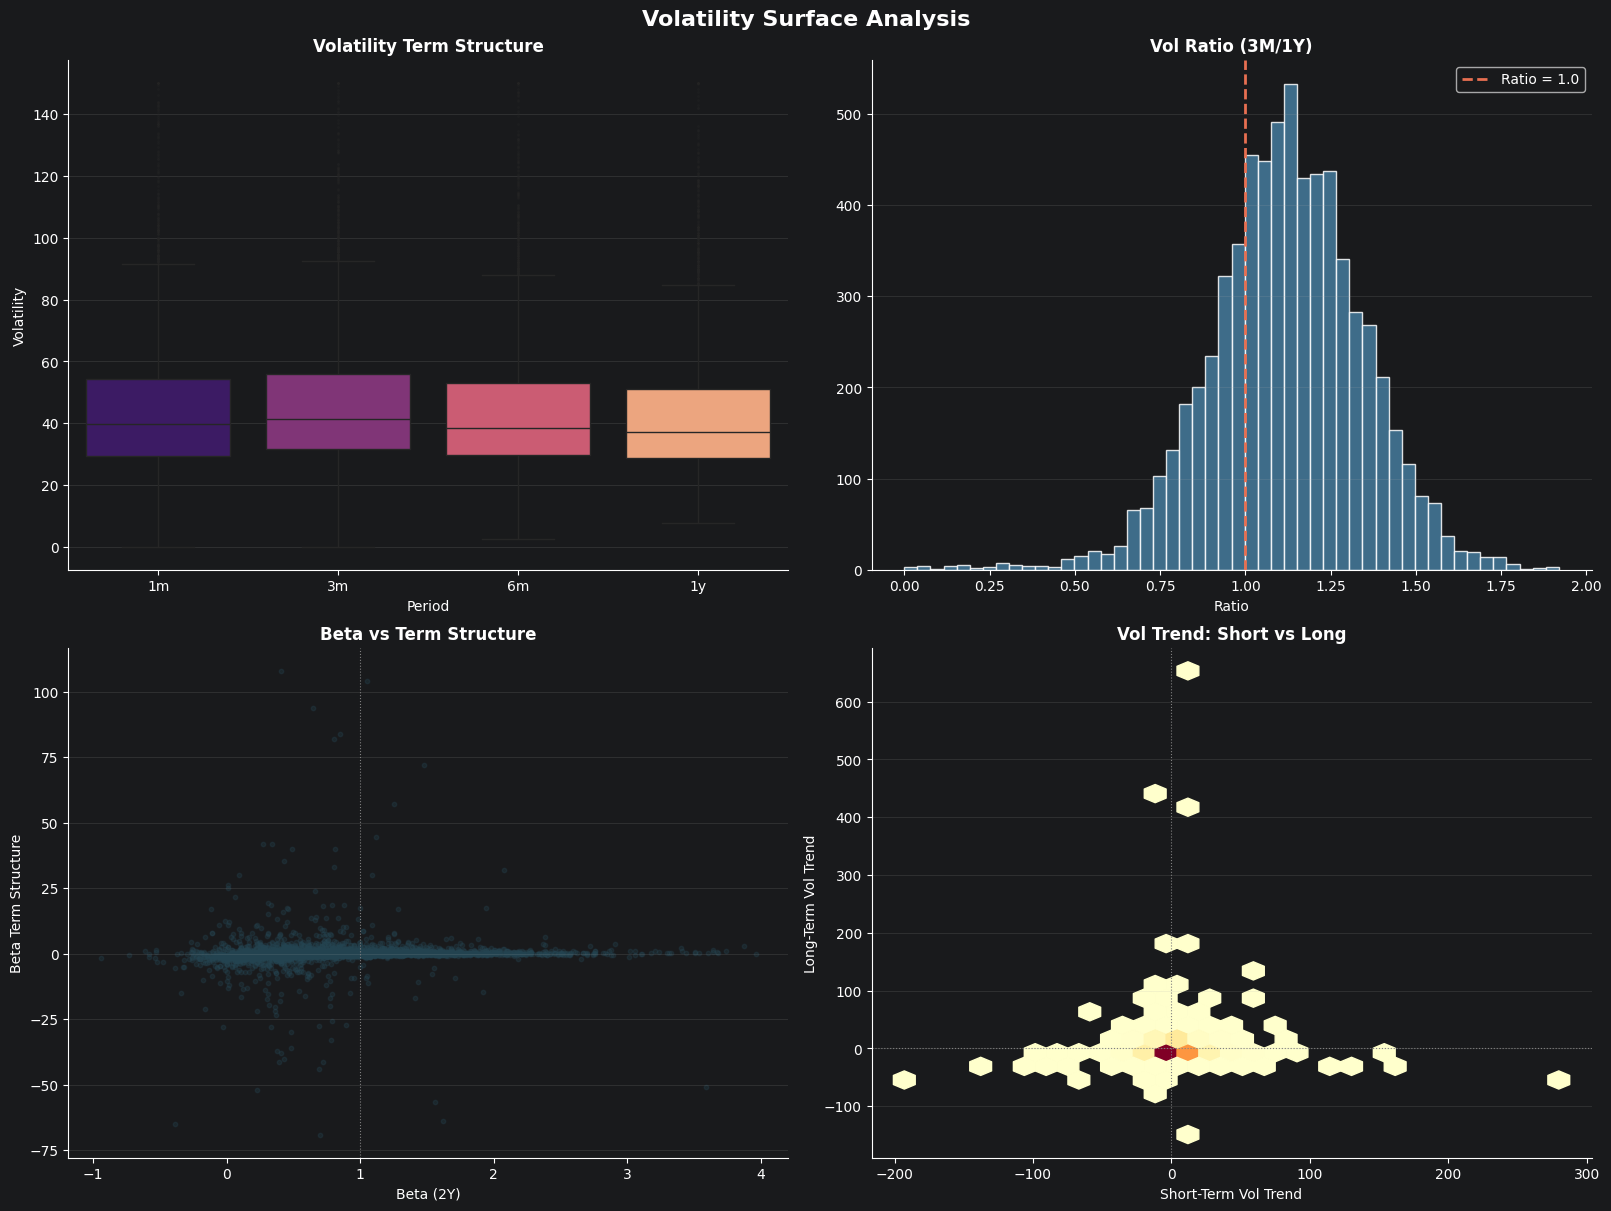

In [90]:
vol_cols = [c for c in FEATURE_CATEGORIES.get("Volatility Surface", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Volatility Surface Analysis", fontsize=16, fontweight="bold")

# Volatility term structure (box plots)
ax = axes[0, 0]
vol_term_cols = [c for c in ["volatility_1m", "volatility_3m", "volatility_6m", "volatility_1y"]
                 if c in df.columns]
if vol_term_cols:
    vol_data = df[vol_term_cols].melt(var_name="Period", value_name="Volatility")
    vol_data["Volatility"] = vol_data["Volatility"].clip(0, 150)
    sns.boxplot(data=vol_data, x="Period", y="Volatility", ax=ax, palette="magma",
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_xticklabels([c.replace("volatility_", "") for c in vol_term_cols])
    ax.set_title("Volatility Term Structure", fontweight="bold")

# Vol ratio 3M/1Y distribution
ax = axes[0, 1]
vr_col = next((c for c in ["vol_ratio_3m_1y"] if c in df.columns), None)
if vr_col:
    vr_data = df[vr_col].dropna().clip(0, 5)
    ax.hist(vr_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(1.0, color=COLORS["danger"], linestyle="--", lw=2, label="Ratio = 1.0")
    ax.set_title("Vol Ratio (3M/1Y)", fontweight="bold")
    ax.set_xlabel("Ratio")
    ax.legend()

# Beta term structure
ax = axes[1, 0]
beta_cols = [c for c in ["beta_2y", "beta_term_structure"] if c in df.columns]
if len(beta_cols) == 2:
    valid = df[beta_cols].dropna()
    valid = valid[valid[beta_cols[0]].between(-1, 4)]
    ax.scatter(valid[beta_cols[0]], valid[beta_cols[1]], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("Beta (2Y)")
    ax.set_ylabel("Beta Term Structure")
    ax.set_title("Beta vs Term Structure", fontweight="bold")
    ax.axvline(1.0, color="grey", linestyle=":", lw=0.8)

# Volatility trend comparison
ax = axes[1, 1]
vt_short = next((c for c in ["volatility_trend_short"] if c in df.columns), None)
vt_long = next((c for c in ["volatility_trend_long"] if c in df.columns), None)
if vt_short and vt_long:
    valid = df[[vt_short, vt_long]].dropna()
    ax.hexbin(valid[vt_short], valid[vt_long], gridsize=30, cmap="YlOrRd", mincnt=1)
    ax.set_xlabel("Short-Term Vol Trend")
    ax.set_ylabel("Long-Term Vol Trend")
    ax.set_title("Vol Trend: Short vs Long", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.axvline(0, color="grey", linestyle=":", lw=0.8)

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 15. Forward Consensus & Estimates (Enhancement 7)

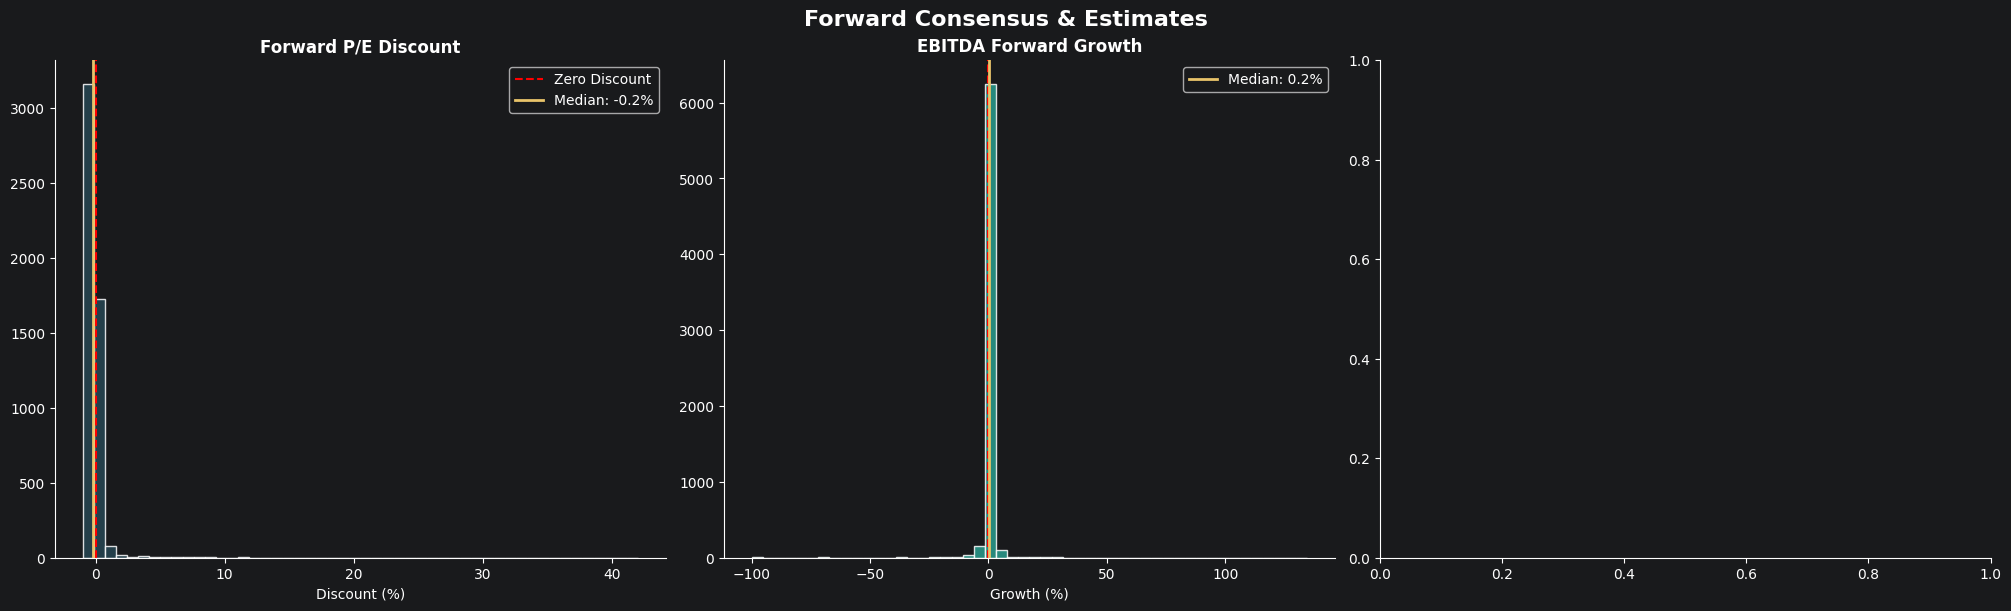

In [91]:
fwd_cols = [c for c in FEATURE_CATEGORIES.get("Forward Consensus", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle("Forward Consensus & Estimates", fontsize=16, fontweight="bold")

# Forward P/E discount distribution
ax = axes[0]
fpe_col = next((c for c in ["pe_forward_discount"] if c in df.columns), None)
if fpe_col:
    fpe_data = df[fpe_col].dropna().clip(-100, 100)
    ax.hist(fpe_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero Discount")
    ax.axvline(fpe_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {fpe_data.median():.1f}%")
    ax.set_title("Forward P/E Discount", fontweight="bold")
    ax.set_xlabel("Discount (%)")
    ax.legend()

# EBITDA forward growth
ax = axes[1]
ebitda_fwd = next((c for c in ["ebitda_forward_growth"] if c in df.columns), None)
if ebitda_fwd:
    ebitda_data = df[ebitda_fwd].dropna().clip(-100, 300)
    ax.hist(ebitda_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.axvline(ebitda_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {ebitda_data.median():.1f}%")
    ax.set_title("EBITDA Forward Growth", fontweight="bold")
    ax.set_xlabel("Growth (%)")
    ax.legend()

# Forward consensus correlation
ax = axes[2]
if len(fwd_cols) >= 3:
    fwd_data = df[fwd_cols].dropna(thresh=len(fwd_cols) // 2)
    if len(fwd_data) > 10:
        corr = fwd_data.corr()
        sns.heatmap(corr, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax,
                    xticklabels=[c[:14] for c in corr.columns],
                    yticklabels=[c[:14] for c in corr.columns], square=True)
        ax.set_title("Forward Consensus Correlations", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
plt.show()

## 16. Enhancement Features: Tax, OpEx, FCF Estimates, Share Dilution

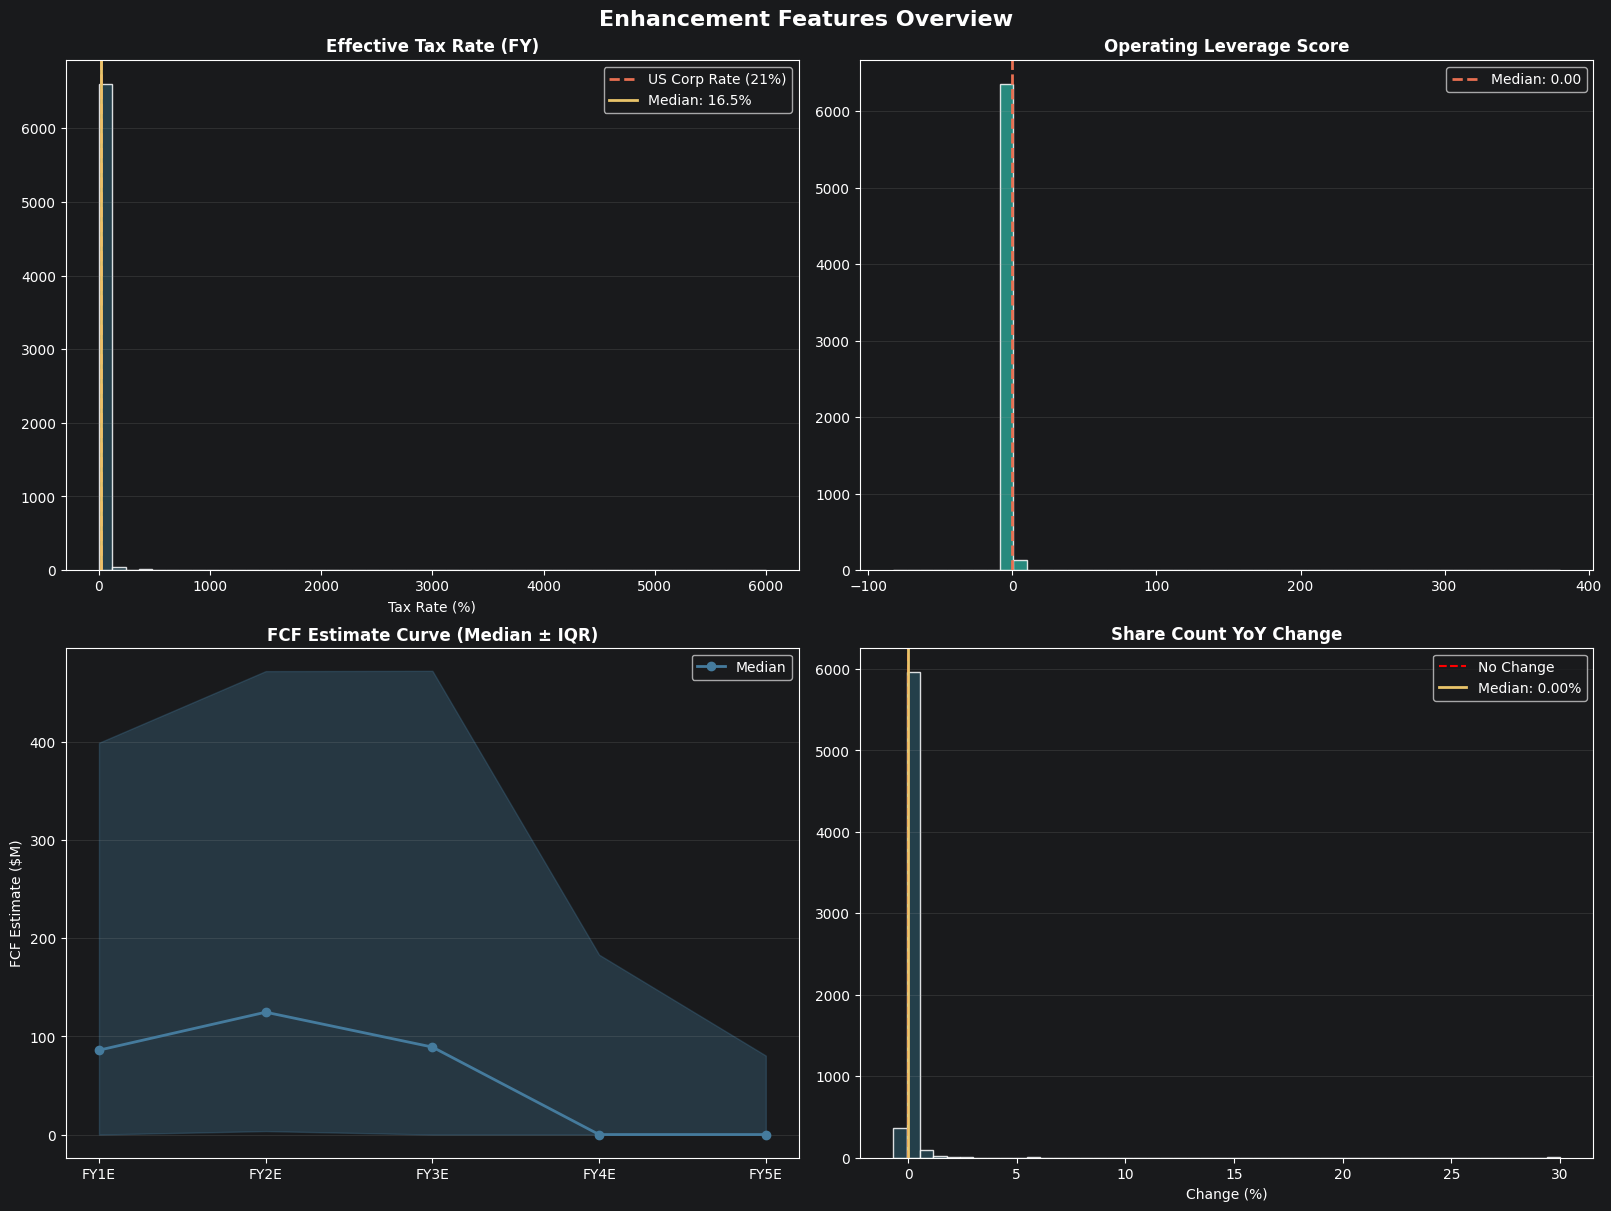

In [92]:
# Tax Rate Features (Enhancement 4)
tax_cols = [c for c in FEATURE_CATEGORIES.get("Tax Rate", []) if c in df.columns]
# OpEx Temporal (Enhancement 5)
opex_cols = [c for c in FEATURE_CATEGORIES.get("OpEx Temporal", []) if c in df.columns]
# FCF Estimates (Enhancement 9)
fcf_est_cols = [c for c in FEATURE_CATEGORIES.get("FCF Estimates", []) if c in df.columns]
# Share Dilution (Enhancement 12)
dilution_cols = [c for c in FEATURE_CATEGORIES.get("Share Dilution", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Enhancement Features Overview", fontsize=16, fontweight="bold")

# Tax rate distribution
ax = axes[0, 0]
tax_col = next((c for c in ["effective_tax_rate_fy"] if c in df.columns), None)
if tax_col:
    tax_data = df[tax_col].dropna().clip(-20, 60) * 100
    ax.hist(tax_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(21, color=COLORS["danger"], linestyle="--", lw=2, label="US Corp Rate (21%)")
    ax.axvline(tax_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {tax_data.median():.1f}%")
    ax.set_title("Effective Tax Rate (FY)", fontweight="bold")
    ax.set_xlabel("Tax Rate (%)")
    ax.legend()

# OpEx operating leverage
ax = axes[0, 1]
olev_col = next((c for c in ["operating_leverage_score"] if c in df.columns), None)
if olev_col:
    olev_data = df[olev_col].dropna()
    ax.hist(olev_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(olev_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {olev_data.median():.2f}")
    ax.set_title("Operating Leverage Score", fontweight="bold")
    ax.legend()

# FCF estimate curve
ax = axes[1, 0]
fcf_fy_cols = [c for c in ["fcf_est_avg_fy1e", "fcf_est_avg_fy2e", "fcf_est_avg_fy3e",
                           "fcf_est_avg_fy4e", "fcf_est_avg_fy5e"] if c in df.columns]
if fcf_fy_cols:
    medians = [df[c].dropna().median() for c in fcf_fy_cols]
    q25 = [df[c].dropna().quantile(0.25) for c in fcf_fy_cols]
    q75 = [df[c].dropna().quantile(0.75) for c in fcf_fy_cols]
    x = range(len(fcf_fy_cols))
    ax.fill_between(x, q25, q75, alpha=0.3, color=COLORS["info"])
    ax.plot(x, medians, "o-", color=COLORS["info"], lw=2, label="Median")
    ax.set_xticks(list(x))
    ax.set_xticklabels(["FY1E", "FY2E", "FY3E", "FY4E", "FY5E"])
    ax.set_title("FCF Estimate Curve (Median ± IQR)", fontweight="bold")
    ax.set_ylabel("FCF Estimate ($M)")
    ax.legend()

# Share dilution tracking
ax = axes[1, 1]
shares_chg = next((c for c in ["shares_yoy_change_pct"] if c in df.columns), None)
if shares_chg:
    chg_data = df[shares_chg].dropna().clip(-30, 30)
    colors_hist = [COLORS["secondary"] if v < 0 else COLORS["danger"] for v in
                   np.histogram_bin_edges(chg_data, bins=50)[:-1]]
    ax.hist(chg_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="No Change")
    ax.axvline(chg_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {chg_data.median():.2f}%")
    ax.set_title("Share Count YoY Change", fontweight="bold")
    ax.set_xlabel("Change (%)")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(True)
    a.spines["right"].set_visible(True)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 17. Dividend History & Asset Sales (Enhancements 8, 10)

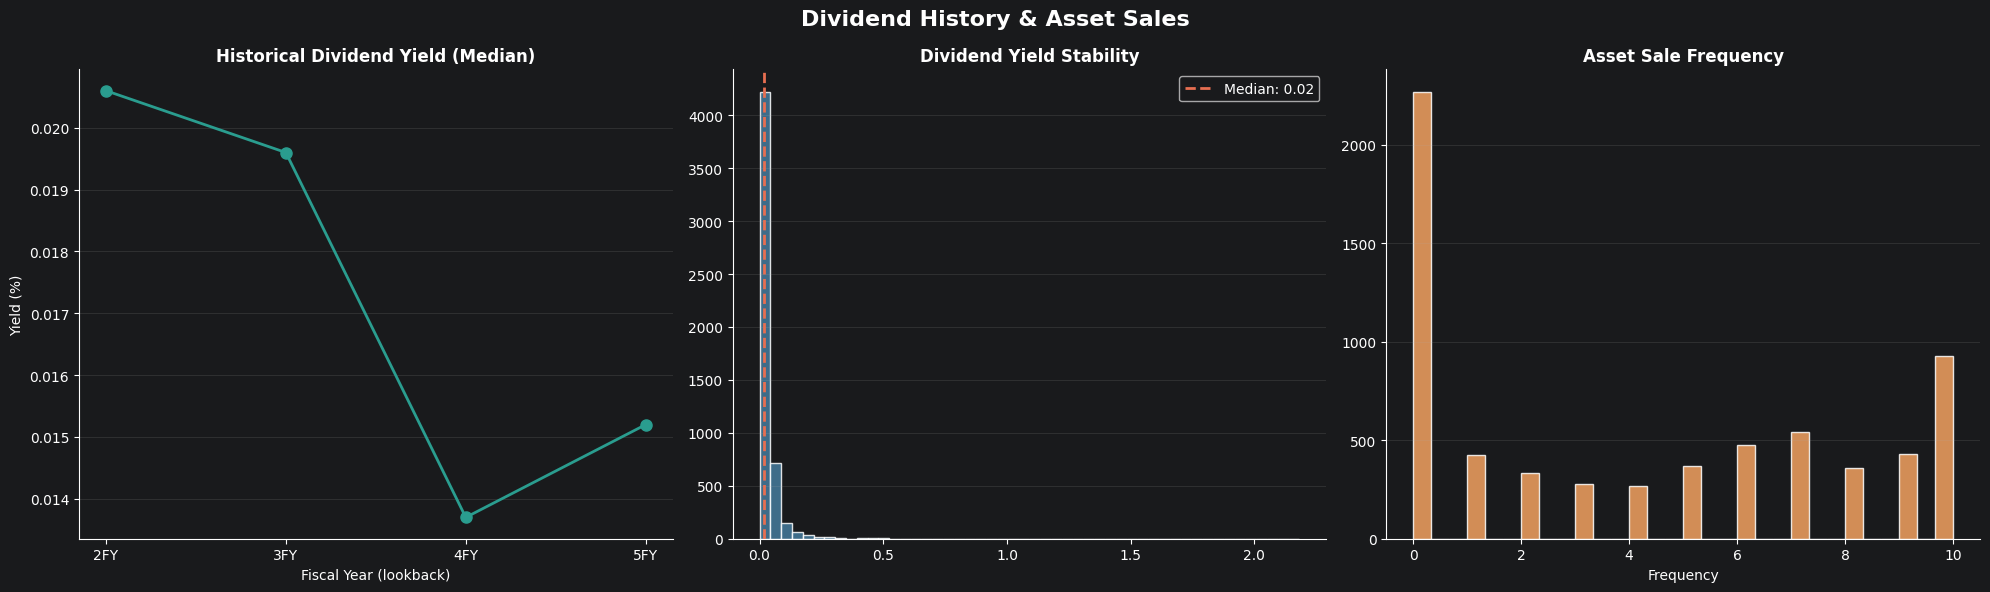

In [93]:
div_hist_cols = [c for c in FEATURE_CATEGORIES.get("Dividend History", []) if c in df.columns]
asset_cols = [c for c in FEATURE_CATEGORIES.get("Asset Sales", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Dividend History & Asset Sales", fontsize=16, fontweight="bold")

# Dividend yield history trend
ax = axes[0]
dy_hist_cols = [c for c in ["div_yield_2fyind", "div_yield_3fyind", "div_yield_4fyind",
                            "div_yield_5fyind"] if c in df.columns]
if dy_hist_cols:
    medians = [df[c].dropna().median() for c in dy_hist_cols]
    ax.plot(range(len(dy_hist_cols)), medians, "o-", color=COLORS["secondary"], lw=2, markersize=8)
    ax.set_xticks(range(len(dy_hist_cols)))
    ax.set_xticklabels(["2FY", "3FY", "4FY", "5FY"])
    ax.set_title("Historical Dividend Yield (Median)", fontweight="bold")
    ax.set_ylabel("Yield (%)")
    ax.set_xlabel("Fiscal Year (lookback)")

# Dividend yield stability
ax = axes[1]
stab_col = next((c for c in ["div_yield_stability"] if c in df.columns), None)
if stab_col:
    stab_data = df[stab_col].dropna()
    ax.hist(stab_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(stab_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {stab_data.median():.2f}")
    ax.set_title("Dividend Yield Stability", fontweight="bold")
    ax.legend()

# Asset sale frequency
ax = axes[2]
asf_col = next((c for c in ["asset_sale_frequency"] if c in df.columns), None)
if asf_col:
    asf_data = df[asf_col].dropna()
    ax.hist(asf_data, bins=30, color=COLORS["light"], alpha=0.85, edgecolor="white")
    ax.set_title("Asset Sale Frequency", fontweight="bold")
    ax.set_xlabel("Frequency")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 18. Interest Income & Employee Productivity (Enhancements 11)

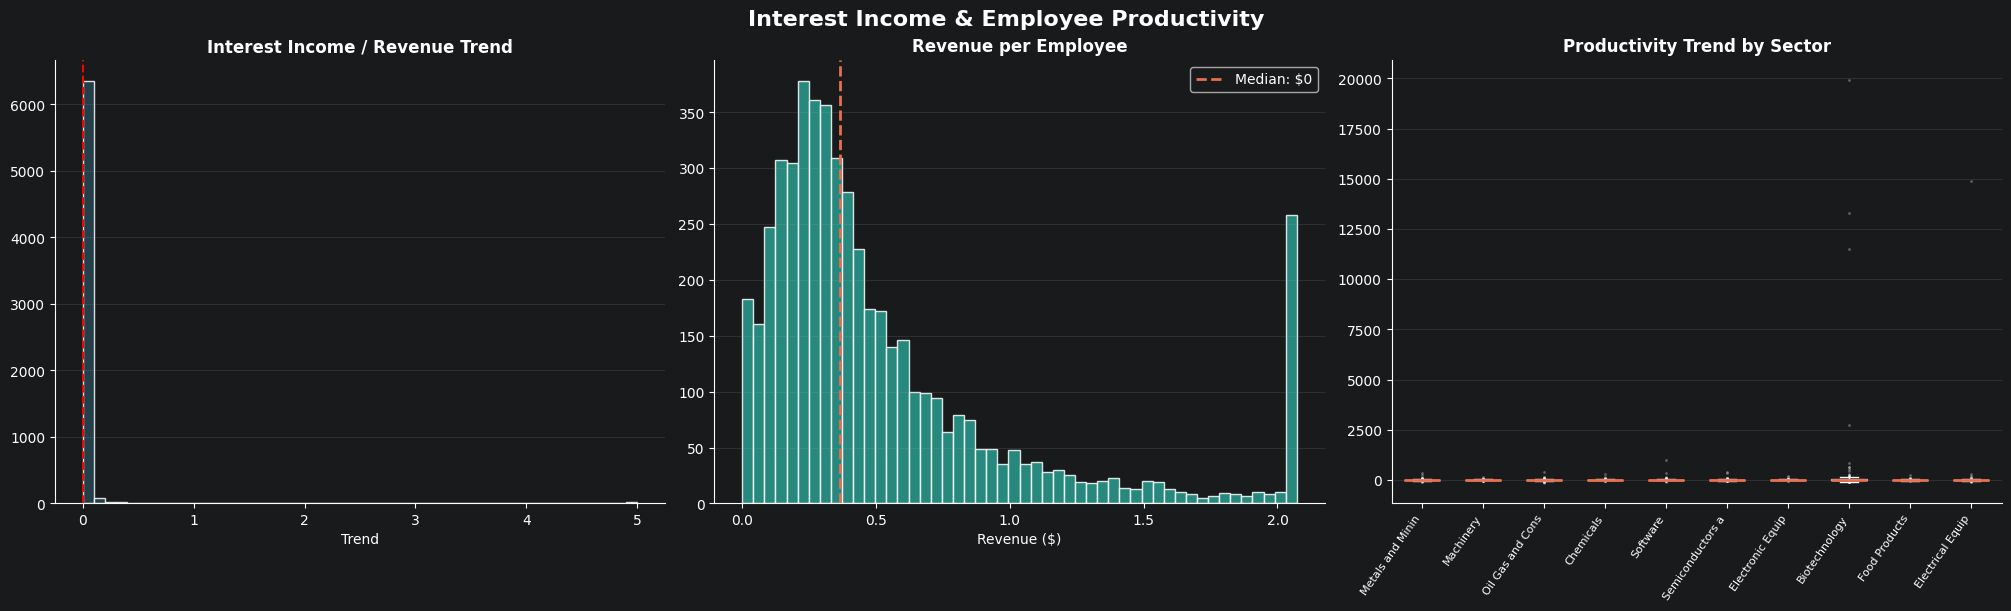

In [94]:
int_cols = [c for c in FEATURE_CATEGORIES.get("Interest Income Temporal", []) if c in df.columns]
emp_cols = [c for c in FEATURE_CATEGORIES.get("Employee Productivity", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle("Interest Income & Employee Productivity", fontsize=16, fontweight="bold")
fig.suptitle("Interest Income & Employee Productivity", fontsize=16, fontweight="bold")

# Interest income to revenue trend
ax = axes[0]
ii_col = next((c for c in ["interest_income_to_revenue_trend"] if c in df.columns), None)
if ii_col:
    ii_data = df[ii_col].dropna().clip(-5, 5)
    ax.hist(ii_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.set_title("Interest Income / Revenue Trend", fontweight="bold")
    ax.set_xlabel("Trend")

# Revenue per employee
ax = axes[1]
rpe_col = next((c for c in ["revenue_per_employee"] if c in df.columns), None)
if rpe_col:
    rpe_data = df[rpe_col].dropna().clip(0, df[rpe_col].dropna().quantile(0.95))
    ax.hist(rpe_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(rpe_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: ${rpe_data.median():,.0f}")
    ax.set_title("Revenue per Employee", fontweight="bold")
    ax.set_xlabel("Revenue ($)")
    ax.legend()

# Productivity trend by sector
ax = axes[2]
prod_col = next((c for c in ["productivity_trend"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if prod_col and sector_col:
    sectors = df[sector_col].value_counts().head(10).index
    prod_data = [df.loc[df[sector_col] == s, prod_col].dropna().values for s in sectors]
    bp = ax.boxplot(prod_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set3(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.set_title("Productivity Trend by Sector", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 19. Cross-Category Correlation Analysis

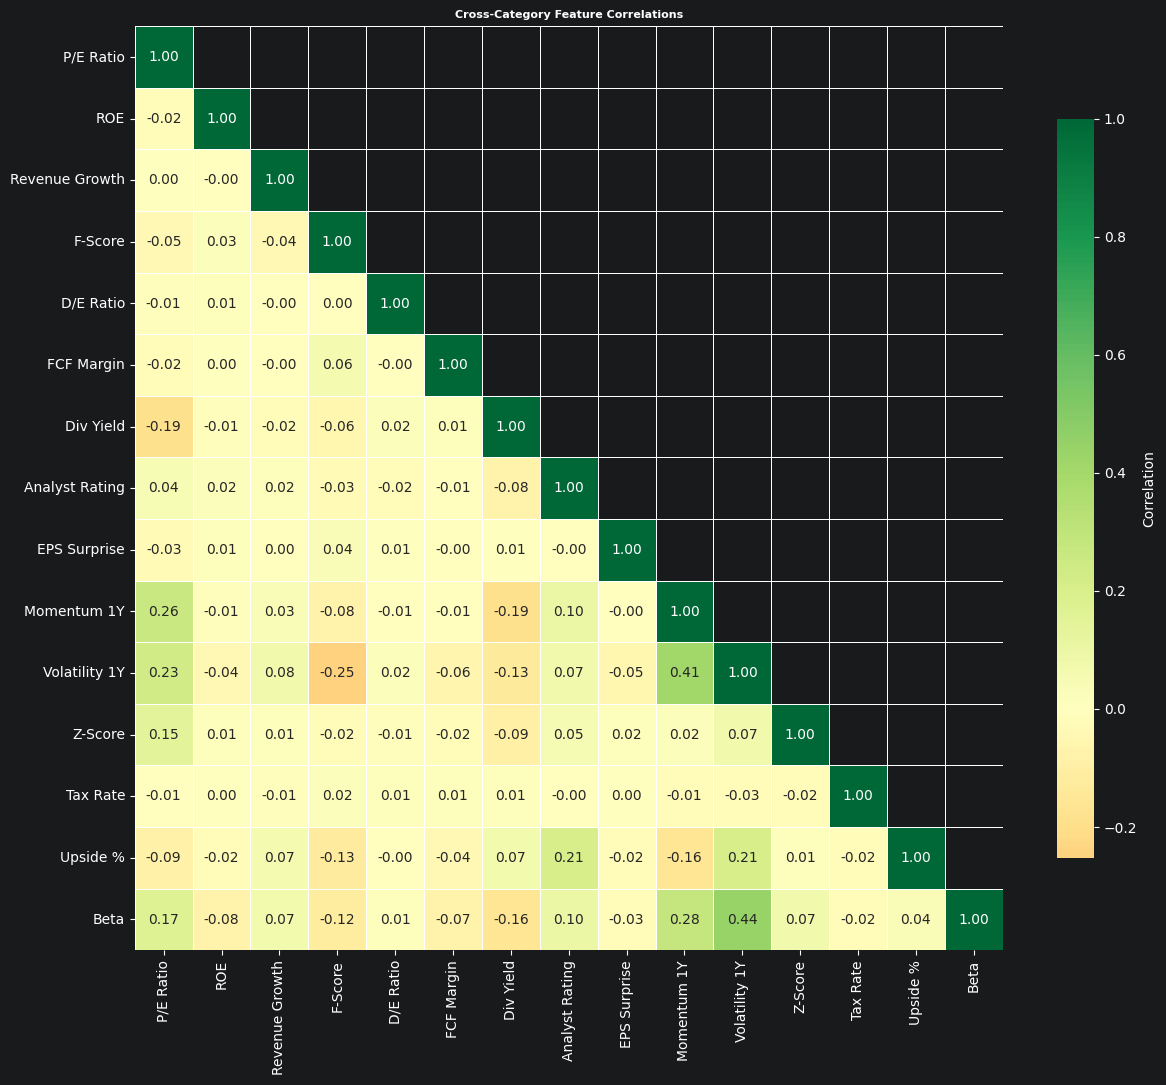

In [95]:
# Select one representative feature per category for the master correlation matrix
representative_features = {
    "P/E Ratio": "p_e_ratio",
    "ROE": "roe",
    "Revenue Growth": "revenue_growth_yoy",
    "F-Score": "piotroski_f_score",
    "D/E Ratio": "debt_to_equity",
    "FCF Margin": "fcf_margin",
    "Div Yield": "dividend_yield_ltm",
    "Analyst Rating": "analyst_rating_normalized",
    "EPS Surprise": "eps_surprise_pct",
    "Momentum 1Y": "price_momentum_1y",
    "Volatility 1Y": "volatility_1y",
    "Z-Score": "altman_z_score",
    "Tax Rate": "effective_tax_rate_fy",
    "Upside %": "upside_potential",
    "Beta": "beta_2y",
}

available_rep = {k: v for k, v in representative_features.items() if v in df.columns}
rep_df = df[list(available_rep.values())].dropna(thresh=len(available_rep) // 2)

fig, ax = plt.subplots(figsize=(14, 12), constrained_layout=False)
corr = rep_df.corr()
corr.columns = list(available_rep.keys())
corr.index = list(available_rep.keys())
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=ax, square=False, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation"})
ax.set_title("Cross-Category Feature Correlations", fontsize=8, fontweight="bold")
plt.show()

## 20. Stock Screening Results

In [96]:
# Enhanced screener: high-quality stocks
quality_stocks = create_enhanced_screener(df, min_fscore=7)
print(f"Enhanced Screener (F-Score ≥ 7): {len(quality_stocks)} stocks")
if len(quality_stocks) > 0:
    display_cols = [c for c in
                    ["ticker", "name", "industry", "piotroski_f_score", "last_price", "price_target", 'p_e_ratio',
                     'peg_ratio', "pe_forward_discount", "forward_pe_premium", "p_e_momentum_yoy", "altman_z_score",
                     "upside_potential", "eps_trajectory_score"] if c in quality_stocks.columns]
    display(quality_stocks[display_cols].head(50))

Enhanced Screener (F-Score ≥ 7): 29 stocks


,ticker,name,industry,piotroski_f_score,last_price,price_target,p_e_ratio,peg_ratio,pe_forward_discount,forward_pe_premium,p_e_momentum_yoy,altman_z_score,upside_potential,eps_trajectory_score
25,LRCX,Lam Research Corporation,Semiconductors and Semiconductor Equipment,9,271.9450,280.9032,65.5000,7.9670,-0.3344,-22.1374,1.6626,11.6100,4.8006,80
701,RL,Ralph Lauren Corporation,Textiles Apparel and Luxury Goods,9,373.9810,408.1375,32.2000,2.4713,-0.3385,-28.5714,0.3473,5.4000,11.7704,60
4103,6857,Advantest Corporation,Semiconductors and Semiconductor Equipment,9,27000.0000,28695.0000,116.5000,7.0004,-0.6601,-49.6137,0.5765,18.7200,11.1111,80
4572,4062,Ibiden Co.Ltd.,Electronic Equipment Instruments and Components,9,9915.0000,8864.1177,82.5000,-6.4037,-0.4545,-20.1212,1.9359,2.4100,-7.2113,80
4295,7747,Asahi Intecc Co. Ltd.,Health Care Equipment and Supplies,9,3493.0000,3829.3333,67.3000,15.2914,-0.5542,-53.3432,0.4857,13.2200,14.5147,60
2198,NSSC,Napco Security Technologies Inc.,Electronic Equipment Instruments and Components,8,43.9450,49.6667,36.9000,1.1785,-0.2168,-18.9702,0.3039,29.2600,12.6408,80
2066,NDSN,Nordson Corporation,Machinery,8,279.8950,308.4286,32.9000,-25.5043,-0.2614,-25.5319,0.1750,4.7800,16.1150,60
5589,002545,Qingdao East Steel Tower Stock Co.Ltd,Metals and Mining,8,22.0000,20.0000,51.8000,8.2670,-0.5367,-53.6680,2.1585,2.5400,-9.0909,60
3444,CEK,CeoTronics AG,Communications Equipment,8,10.9200,18.0500,19.3000,1.0506,-0.2746,-18.1347,0.0000,7.4500,65.2930,60
2702,RYA,Ryanair Holdings plc,Passenger Airlines,8,25.5800,32.1632,19.0000,NaN,-0.4053,-35.7895,0.1801,4.0200,25.0977,60


In [97]:
# Value opportunities
value_stocks = screen_value_opportunities(df)
print(f"\nValue Opportunities: {len(value_stocks)} stocks")
if len(value_stocks) > 0:
    display_cols = [c for c in
                    ["ticker", "name", "p_e_ratio", "pe_forward_discount", "forward_pe_premium", "p_e_momentum_yoy",
                     "upside_potential",
                     "price_to_tangible_book"] if c in value_stocks.columns]
    display(value_stocks[display_cols].head(50))


Value Opportunities: 1451 stocks


,ticker,name,p_e_ratio,pe_forward_discount,forward_pe_premium,p_e_momentum_yoy,upside_potential,price_to_tangible_book
9,XOM,Exxon Mobil Corporation,22.0000,-0.3045,-30.4545,-0.0222,13.1007,2.4000
10,MARS,Marston's PLC,5.1000,0.2157,21.5686,-0.0377,47.3214,0.5000
18,CVX,Chevron Corporation,28.0000,-0.3714,-37.1429,0.0000,16.1850,2.0000
38,JULPHAR,Gulf Pharmaceutical Industries P.S.C.,28.3000,-0.5866,-58.6572,0.0366,63.8095,1.3000
43,BABA,Alibaba Group Holding Limited,17.7000,0.1186,46.3277,0.2041,43.3569,2.6000
45,RACC,Raya Customer Experience,6.0000,-0.0333,-3.3333,-0.0909,63.6156,1.5000
64,ASSAD,L'Accumulateur Tunisien Assad SA,22.4000,-0.5625,-56.2500,1.1132,-26.1981,3.3000
75,COST,Costain Group PLC,14.3000,-0.0979,-9.7902,0.0362,11.1963,2.5000
80,FAA,Fabasoft AG,14.6000,-0.0274,-2.7397,-0.3081,130.4147,3.4000
82,SPAN,Span d.d.,19.8000,0.0556,5.5556,-0.2903,50.0000,4.3000


In [98]:
# Growth momentum stocks
growth_stocks = screen_growth_momentum(df)
print(f"\nGrowth Momentum: {len(growth_stocks)} stocks")
if len(growth_stocks) > 5:
    display_cols = [c for c in ["ticker", "name", "revenue_growth_yoy",
                                "eps_yoy_growth", "price_momentum_1y", "eps_momentum_yoy"] if
                    c in growth_stocks.columns]
    display(growth_stocks[display_cols].head(50))


Growth Momentum: 2894 stocks


,ticker,name,revenue_growth_yoy,eps_yoy_growth,price_momentum_1y
1073,AAOI,Applied Optoelectronics Inc.,82.7445,85.7778,1225.5822
4132,5803,Fujikura Ltd.,23.5968,85.0000,665.3127
5418,6442,EZconn Corporation,71.8979,70.4545,546.4174
4520,A298040,Hyosung Heavy Industries Corporation,24.7290,138.9129,586.6817
429,CLS,Celestica Inc.,28.4564,99.4475,378.6745
4704,6223,MPI Corporation,37.5969,44.5946,661.2688
4369,A267260,HD Hyundai Electric Co. Ltd.,25.6073,49.3644,245.6026
6360,CEPU,Central Puerto S.A.,5.5841,300.0000,65.0694
4847,522275,GE Vernova T&D India Limited,32.1497,250.0000,207.1833
6128,ASELS,ASELSAN Elektronik Sanayi ve Ticaret Anonim Si...,23.7036,66.6667,248.3641


In [99]:
# Dividend quality stocks
div_stocks = screen_dividend_quality(df)
print(f"\nDividend Quality: {len(div_stocks)} stocks")
if len(div_stocks) > 0:
    display_cols = [c for c in ["ticker", "name", "dividend_yield_ltm",
                                "dividend_streak", "fcf_dividend_coverage"] if c in div_stocks.columns]
    display(div_stocks[display_cols].head(50))


Dividend Quality: 600 stocks


,ticker,name,dividend_yield_ltm,dividend_streak,fcf_dividend_coverage
1423,CAG,Conagra Brands Inc.,0.0977,1,1.2582
6597,EVEN3,Even Construtora e Incorporadora S.A.,0.0962,2,0.5924
2390,UPBD,Upbound Group Inc.,0.0791,8,2.7169
2276,NOMD,Nomad Foods Limited,0.0788,1,2.7624
3599,DNO,DNO ASA,0.0756,6,0.6806
2810,SOMA,Solstad Maritime ASA,0.0742,0,1.5525
4338,CSED3,Cruzeiro do Sul Educacional S.A.,0.0738,3,4.3807
616,KHC,The Kraft Heinz Company,0.0723,1,1.9289
5530,UNVR,PT Unilever Indonesia Tbk,0.0720,2,0.9682
825,GIS,General Mills Inc.,0.0713,7,1.2524


In [100]:
# Financially healthy stocks
healthy_stocks = screen_financial_health(df)
print(f"\nFinancial Health: {len(healthy_stocks)} stocks")
if len(healthy_stocks) > 0:
    display_cols = [c for c in ["ticker", "name", "altman_z_score",
                                "current_ratio", "interest_coverage"] if c in healthy_stocks.columns]
    display(healthy_stocks[display_cols].head(50))


Financial Health: 1048 stocks


,ticker,name,altman_z_score,current_ratio,interest_coverage
6671,COPN,Cosmo Pharmaceuticals N.V.,6.5000,7.2000,58.2143
2,ALL,Atlantic Lithium Limited,18.9200,2.1000,20.5625
14,DVYSR,Devyser Diagnostics AB (publ),11.0300,2.9000,-3.8182
6666,GRNG,Gränges AB (publ),3.0700,1.3000,-6.0190
32,2718,Mininglamp Technology,NaN,2.5000,1.4956
6584,LILAK,Lila Kagit Sanayi Ve Ticaret A.S.,5.1700,5.9000,-7.7468
6568,6017,Jahez International Company for Information Sy...,4.3300,1.0000,-6.8819
6566,4192,Al-Saif Stores for Development & Investment Co...,7.1100,3.8000,-6.4583
6561,RLO,Reunert Limited,4.2000,2.6000,-8.2939
6559,FORUS,Forus S.A.,5.1000,3.2000,-7.4215


## 21. Composite Rankings

Ranked 6677 stocks by composite score

Top 20 by Composite Score:


,ticker,name,industry,composite_score
701,RL,Ralph Lauren Corporation,Textiles Apparel and Luxury Goods,100.0000
0,AAPL,Apple Inc.,Technology Hardware Storage and Peripherals,97.5000
671,KFY,Korn Ferry,Professional Services,97.5000
25,LRCX,Lam Research Corporation,Semiconductors and Semiconductor Equipment,97.5000
1103,AIT,Applied Industrial Technologies Inc.,Trading Companies and Distributors,97.2222
1425,EAT,Brinker International Inc.,Hotels Restaurants and Leisure,97.2222
827,BR,Broadridge Financial Solutions Inc.,Professional Services,97.2222
611,CASY,Casey's General Stores Inc.,Consumer Staples Distribution and Retail,97.2222
55,KLAC,KLA Corporation,Semiconductors and Semiconductor Equipment,94.7222
1027,SKY,Champion Homes Inc.,Household Durables,94.7222


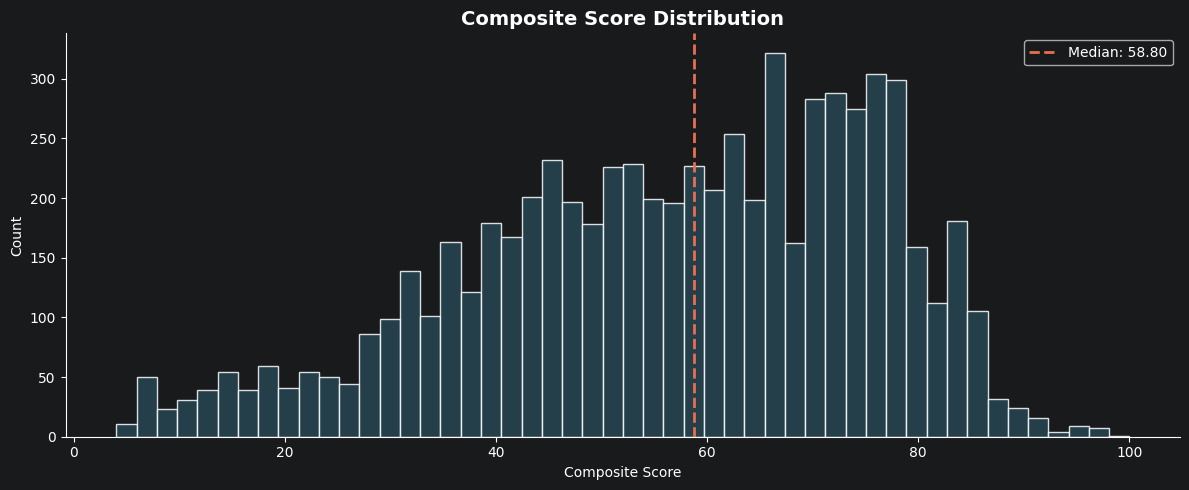

In [101]:
# Rank stocks by composite score
ranked_df = rank_stocks_by_composite_score(df)
print(f"Ranked {len(ranked_df)} stocks by composite score")
if "composite_score" in ranked_df.columns:
    display_cols = [c for c in ["ticker", "name", "industry", "composite_score"]
                    if c in ranked_df.columns]
    print("\nTop 20 by Composite Score:")
    display(ranked_df[display_cols].head(50))

    # Composite score distribution
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(ranked_df["composite_score"].dropna(), bins=50, color=COLORS["primary"],
            alpha=0.85, edgecolor="white")
    ax.axvline(ranked_df["composite_score"].median(), color=COLORS["danger"],
               linestyle="--", lw=2, label=f"Median: {ranked_df['composite_score'].median():.2f}")
    ax.set_title("Composite Score Distribution", fontsize=14, fontweight="bold")
    ax.set_xlabel("Composite Score")
    ax.set_ylabel("Count")
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

## 22. Statistical Analysis: Bayesian Category Analysis

In [102]:
# Bayesian analysis on ALL feature categories (excluding "direct" calculation_type features)

# Build a set of features with "direct" calculation_type to exclude
direct_features = set(
    feature_cat.loc[feature_cat["calculation_type"] == "direct", "feature_alias"].tolist()
)
print(f"Excluding {len(direct_features)} features with calculation_type='direct'")

for cat_name, features in FEATURE_CATEGORIES.items():
    # Filter out "direct" features and keep only those present in df
    available = [f for f in features if f in df.columns and f not in direct_features]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Bayesian Analysis: {cat_name} ({len(available)} features)")
        print(f"{'=' * 60}")
        result = bayesian_category_analysis(df, cat_name, available)
        if isinstance(result, dict):
            for feat, stats in result.items():
                if isinstance(stats, dict):
                    print(f"\n  {feat}:")
                    for k, v in stats.items():
                        if isinstance(v, (int, float)):
                            print(f"    {k}: {v:.4f}")
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {cat_name}: {skipped_reason}")

Excluding 405 features with calculation_type='direct'

  Bayesian Analysis: Accounting Quality (20 features)

  goodwill_change_rate:
    n_obs: 4739.0000
    sample_mean: 2.1161
    sample_std: 85.4811
    posterior_mean: 2.0840
    posterior_std: 1.2323
    ci_95_low: -0.3313
    ci_95_high: 4.4992
    prob_positive: 0.9546

  restructuring_intensity:
    n_obs: 6321.0000
    sample_mean: -0.0016
    sample_std: 0.0070
    posterior_mean: -0.0016
    posterior_std: 0.0001
    ci_95_low: -0.0018
    ci_95_high: -0.0014
    prob_positive: 0.0000

  exceptional_items_frequency:
    n_obs: 6677.0000
    sample_mean: 0.5781
    sample_std: 0.6986
    posterior_mean: 0.5781
    posterior_std: 0.0085
    ci_95_low: 0.5613
    ci_95_high: 0.5949
    prob_positive: 1.0000

  merger_impact_ratio:
    n_obs: 6677.0000
    sample_mean: -0.0041
    sample_std: 0.0333
    posterior_mean: -0.0041
    posterior_std: 0.0004
    ci_95_low: -0.0049
    ci_95_high: -0.0033
    prob_positive: 0.0000

  n

## 23. Distribution Fitting by Category

In [106]:
# Fit statistical distributions to ALL feature categories
# (reuses the same direct_features exclusion set built in cell 22)

for cat_name, features in FEATURE_CATEGORIES.items():
    available = [f for f in features if f in df.columns and f not in direct_features]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Distribution Fitting: {cat_name} ({len(available)} features)")
        print(f"{'=' * 60}")
        result = fit_distributions_by_category(df, cat_name, available, n_simulations=5000)
        if isinstance(result, dict):
            for feat, info in result.items():
                if isinstance(info, dict) and "best_distribution" in info:
                    print(
                        f"  {feat}: best_distribution={info['best_distribution']}, "
                        f"aic={info.get('aic', 'N/A'):.4f}, "
                        f"params={info.get('params', 'N/A')}, "
                        f"simulated_mean={info.get('simulated_mean', 'N/A'):.4f}, "
                        f"simulated_std={info.get('simulated_std', 'N/A'):.4f}, "
                        f"cvar_5_pct={info.get('cvar_5_pct', 'N/A'):.4f}"
                    )
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {cat_name}: {skipped_reason}")


  Distribution Fitting: Accounting Quality (20 features)
  goodwill_change_rate: best_distribution=student_t, aic=2527.6099, params=(np.float64(0.7144620618946163), np.float64(0.03755682360760671), np.float64(0.0659563797333384)), simulated_mean=0.2655, simulated_std=17.1059, cvar_5_pct=-10.6716
  restructuring_intensity: best_distribution=skew_normal, aic=-61086.9643, params=(np.float64(-870497.6420764877), np.float64(2.1144888727373436e-08), np.float64(0.003513880780102138)), simulated_mean=-0.0028, simulated_std=0.0021, cvar_5_pct=-0.0082
  exceptional_items_frequency: best_distribution=skew_normal, aic=8391.2675, params=(np.float64(5150288.796983473), np.float64(-9.259684895430425e-07), np.float64(0.9066865007735887)), simulated_mean=0.7315, simulated_std=0.5441, cvar_5_pct=0.0280
  merger_impact_ratio: best_distribution=skew_normal, aic=-54858.8887, params=(np.float64(-4392335.52523841), np.float64(9.295623040800917e-09), np.float64(0.007309342596911496)), simulated_mean=-0.0058,

## 24. Sector-Level Summary Dashboard

Sector-Level Summary:


,count,median_pe,median_roe,median_momentum,median_upside
industry,,,,,
Metals and Mining,357,24.0500,0.0814,89.6549,15.7470
Machinery,322,28.0000,0.1132,37.9209,14.8695
Oil Gas and Consumable Fuels,288,16.1000,0.0981,46.6225,11.8414
Chemicals,276,27.7000,0.0594,33.9272,9.6108
Software,256,30.6000,0.0794,-8.8829,47.1056
Semiconductors and Semiconductor Equipment,253,59.1000,0.0795,98.1874,5.2086
Electronic Equipment Instruments and Components,250,37.6000,0.0994,60.4642,10.3904
Biotechnology,243,27.9000,-0.2887,59.7168,42.4907
Food Products,241,17.8000,0.1112,8.9174,15.4973


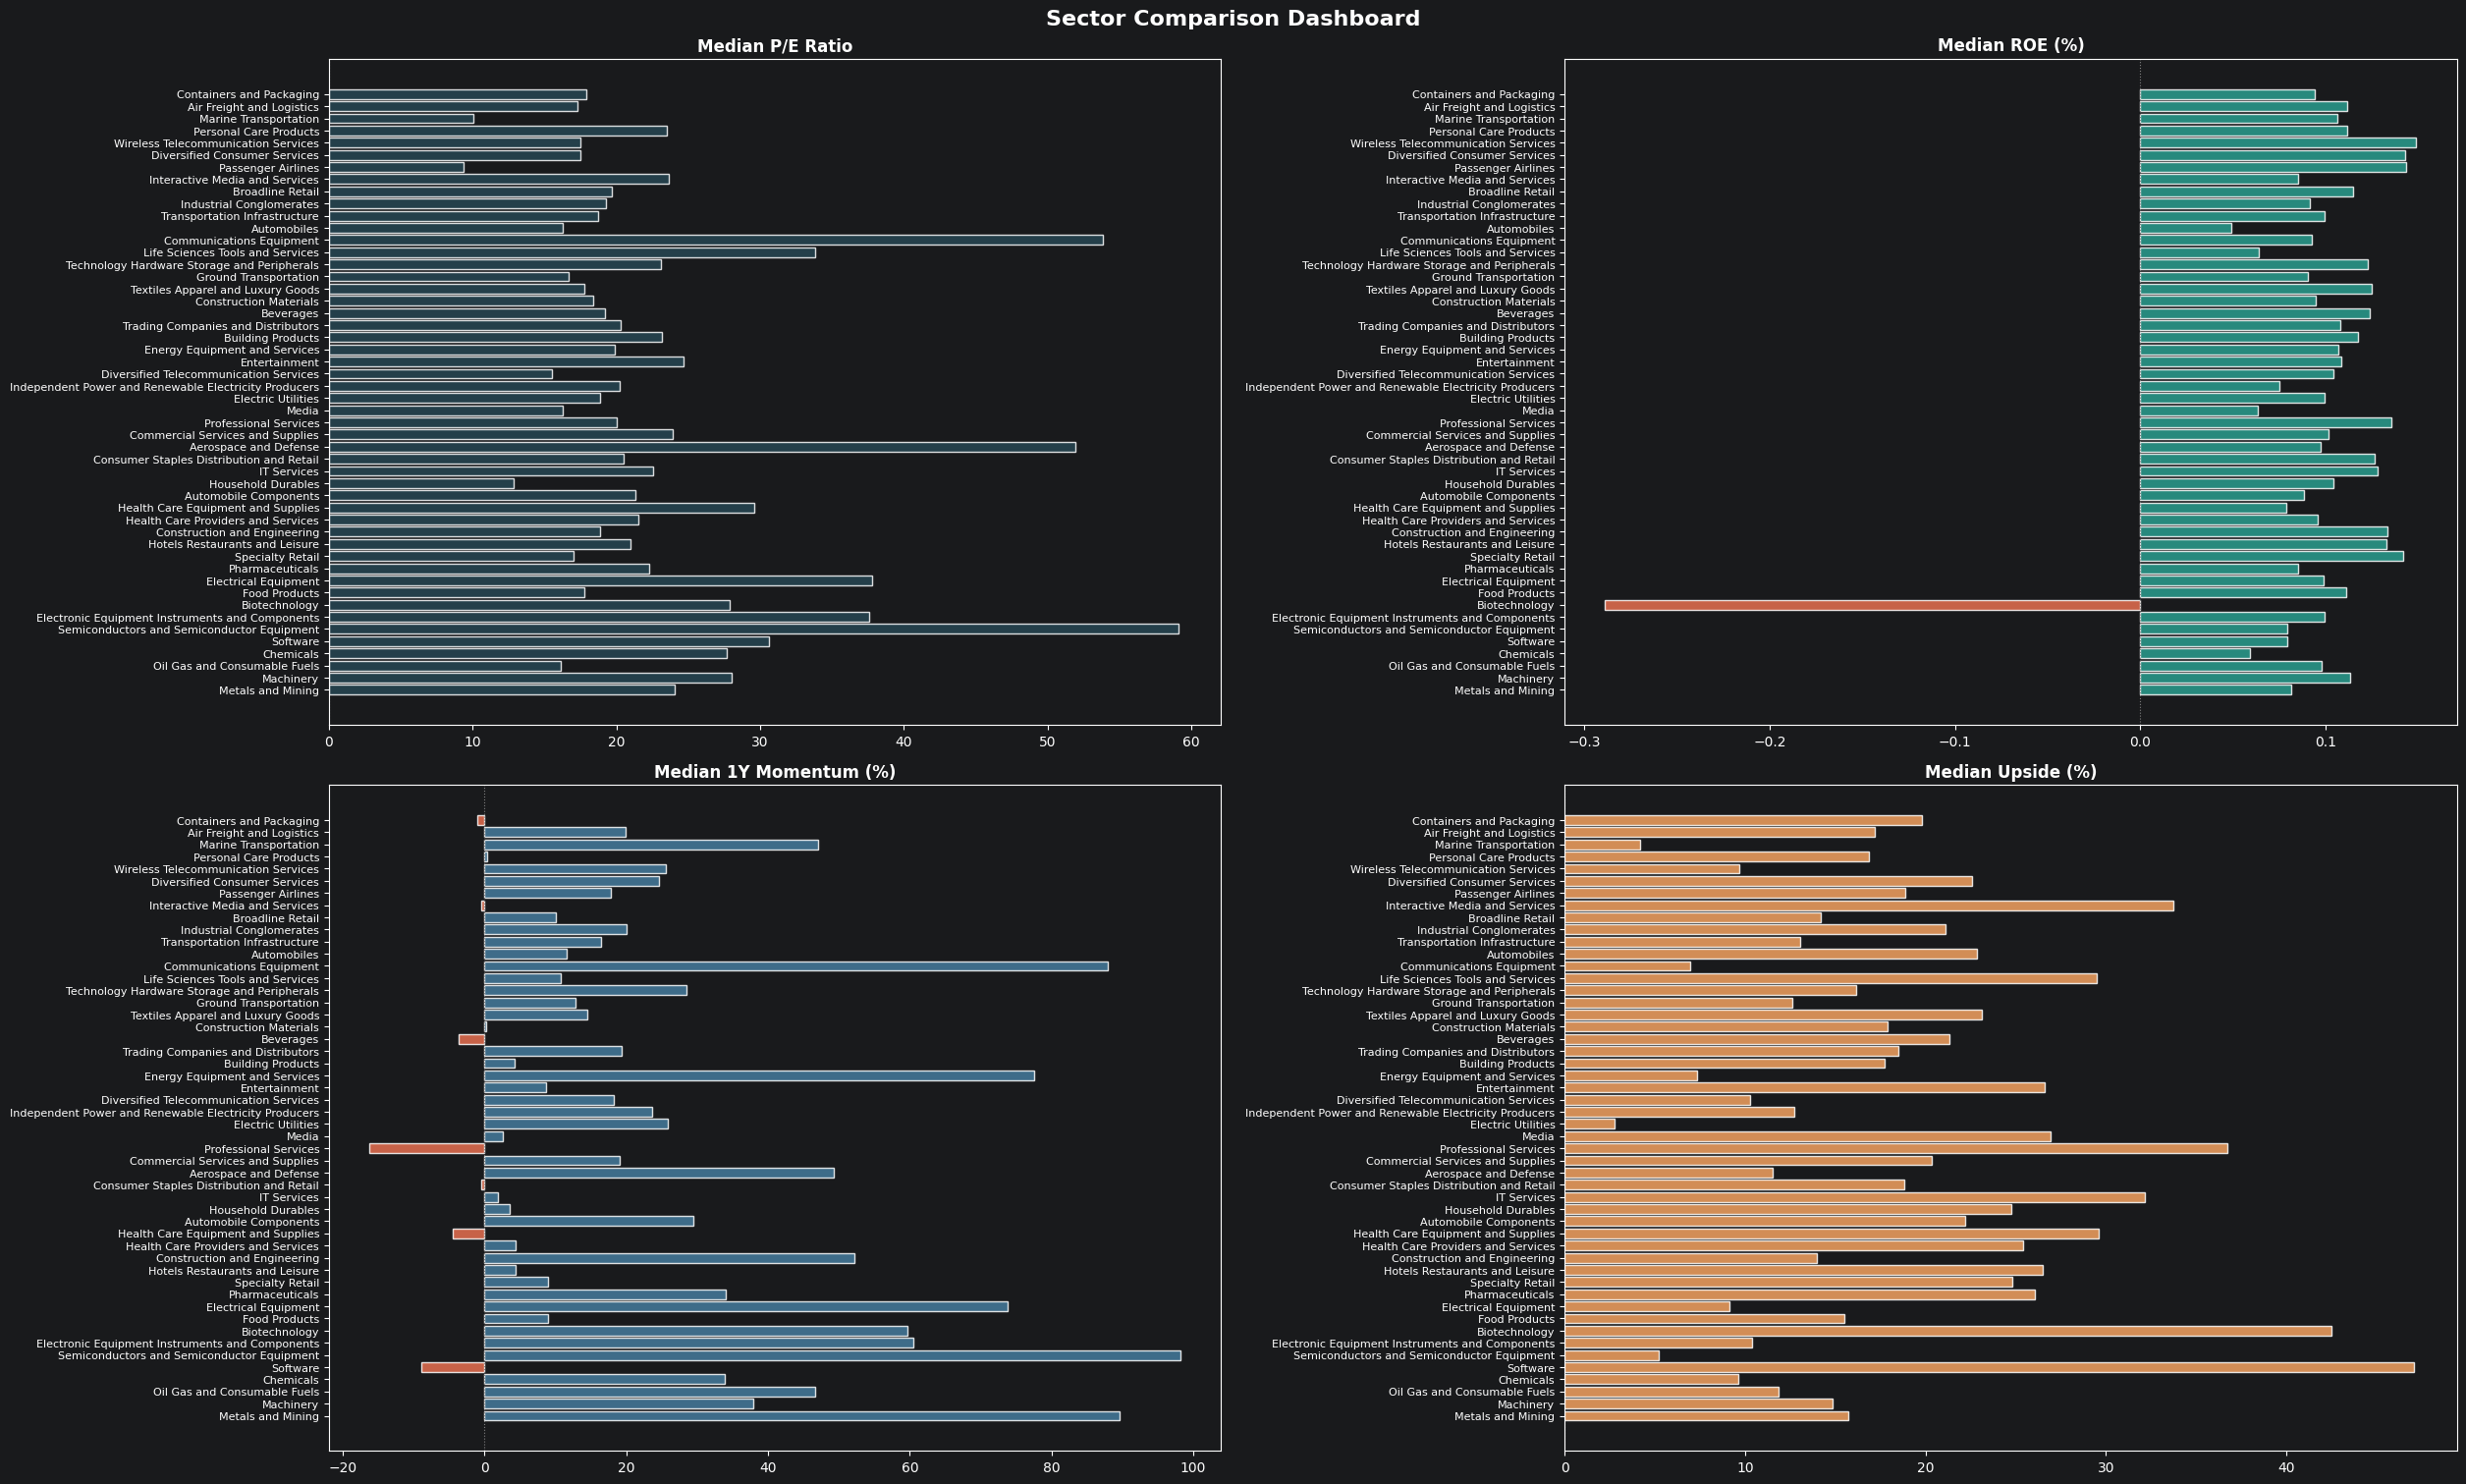

In [104]:
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if sector_col:
    sector_metrics = df.groupby(sector_col).agg(
        count=("ticker", "count"),
        median_pe=("p_e_ratio", "median") if "p_e_ratio" in df.columns else ("ticker", "count"),
        median_roe=("roe", "median") if "roe" in df.columns else ("ticker", "count"),
        median_momentum=("price_momentum_1y", "median") if "price_momentum_1y" in df.columns else ("ticker", "count"),
        median_upside=("upside_potential", "median") if "upside_potential" in df.columns else ("ticker", "count"),
    ).sort_values("count", ascending=False)

    print("Sector-Level Summary:")
    display(sector_metrics.head(50))

    # Sector comparison radar-style bar chart
    fig, axes = plt.subplots(2, 2, figsize=(25, 15), constrained_layout=True)
    fig.suptitle("Sector Comparison Dashboard", fontsize=16, fontweight="bold")

    metrics_to_plot = [
        ("median_pe", "Median P/E Ratio", COLORS["primary"]),
        ("median_roe", "Median ROE (%)", COLORS["secondary"]),
        ("median_momentum", "Median 1Y Momentum (%)", COLORS["info"]),
        ("median_upside", "Median Upside (%)", COLORS["light"]),
    ]

    top_sectors = sector_metrics.head(50)
    for idx, (col, title, color) in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        if col in top_sectors.columns:
            vals = top_sectors[col].fillna(0)
            bar_colors = [COLORS["danger"] if v < 0 else color for v in vals]
            ax.barh(top_sectors.index, vals, color=bar_colors, edgecolor="white", alpha=0.85)
            ax.set_title(title, fontweight="bold")
            ax.axvline(0, color="grey", linestyle=":", lw=0.8)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
        ax.tick_params(axis="y", labelsize=8)

    plt.show()

## 25. Core PML Bayesian Modeling (PyMC & ArviZ)

This section implements the next-generation probabilistic models using PyMC for full Bayesian inference. Unlike the baseline models above, these models produce full posterior distributions, allowing for advanced risk analysis and uncertainty quantification.

### 25.1 Monte Carlo Return Simulation
Generates probabilistic return distributions with learnable mean/variance priors.


In [ ]:
from probabilistic_ml_model.pml_models.MonteCarloSimulation import fit as mc_fit

pml_df = df.copy()
mu_col = "total_return_ytd"
std_col = "volatility_1y"

valid_mask = (
        pml_df[mu_col].notna() &
        pml_df[std_col].notna() &
        (pml_df[std_col] > 0)
)

pml_df_valid = pml_df[valid_mask].copy()

if len(pml_df_valid) > 0:
    print(f"Running Monte Carlo Simulation for {len(pml_df_valid)} stocks...")
    mc_idata = mc_fit(
        historical_means=pml_df_valid[mu_col].values / 100,
        historical_stds=pml_df_valid[std_col].clip(lower=1.0).values / 100,
        tickers=pml_df_valid["ticker"].values,
        n_sims=1_000,
        samples=500,
        tune=500,
        chains=2,
        target_accept=0.90,
    )
    print("Monte Carlo simulation complete.")
    print(mc_idata)

    # Posterior diagnostics
    az.plot_posterior(mc_idata, var_names=["mu_return"], coords={"ticker": pml_df_valid["ticker"].values[:5]})
    plt.suptitle("Monte Carlo: mu_return Posterior (first 5 tickers)")
    plt.show()
else:
    print("No valid stocks to simulate.")

### 25.2 Kalman Filter Price Targets
Noise-reduced price target signals using state-space modeling.


In [ ]:
kf_model = KalmanFilterPriceTarget()
pt_col = "price_target"  # DDL: numeric

# Cross-sectional: use all tickers' consensus price targets as observed series
pt_values = pml_df[pt_col].dropna().values

if len(pt_values) >= 5:
    example_ticker = pml_df.loc[pml_df[pt_col].notna(), "ticker"].iloc[0]
    print(f"Running Kalman Filter for {example_ticker} ({len(pt_values)} observations)...")
    kf_idata = kf_model.fit(
        price_targets=pt_values,
        ticker=example_ticker,
        samples=2000,
        tune=1000,
    )

    # Plotting filtered state
    az.plot_posterior(kf_idata, var_names=["state"], coords={"time": [len(pt_values) - 1]})
    plt.title(f"Kalman Filtered Price Target Posterior (T={len(pt_values)}) for {example_ticker}")
    plt.show()
else:
    print(f"Insufficient price target data ({len(pt_values)} obs) — skipping Kalman Filter.")


### 25.3 Accounting Anomaly Detection (Bayesian)
Multi-layered statistical anomaly detection via Mahalanobis distance.


In [ ]:
anomaly_bayesian = AccountingAnomalyBayesian(threshold=2.5)

# Multi-category anomaly features verified against DDL
anomaly_feature_cols = [
    "eps_surprise_pct", "eps_adjustment_ratio", "gaap_adj_eps_gap_pct",
    "ebitda_adjustment_ratio", "earnings_quality_score",
    "ni_adjustment_ratio", "cfo_to_net_income", "accounting_quality_score",
    "debt_to_equity", "current_ratio",
]
anomaly_features = [f for f in anomaly_feature_cols if f in pml_df.columns][:10]

if len(anomaly_features) >= 3:
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    feat_vals = scaler.fit_transform(pml_df[anomaly_features].fillna(0).values)

    print(f"Running Bayesian Anomaly Detection using: {anomaly_features}")
    anomaly_idata = anomaly_bayesian.fit(
        feature_values=feat_vals,
        tickers=pml_df["ticker"].values,
        feature_names=anomaly_features,
        samples=2000,
        tune=1000,
    )

    # Visualization
    az.plot_forest(anomaly_idata, var_names=["anomaly_prob"], combined=True)
    plt.title("Bayesian Anomaly Probability Posterior")
    plt.show()


### 25.4 Credit Risk / Distress Estimation
Bayesian distress estimation with Altman Z-score and Debt-to-Equity signals.


In [ ]:
credit_bayesian = CreditRiskBayesian()
z_col = "altman_z_score"  # DDL: numeric, Quality & Risk category
de_col = "debt_to_equity"  # DDL: numeric, Leverage & Liquidity category

valid_mask = pml_df[z_col].notna() & pml_df[de_col].notna()
cr_df = pml_df[valid_mask]

if len(cr_df) > 0:
    print(f"Running Bayesian Credit Risk Model for {len(cr_df)} stocks...")
    # Pass combined_distress_score as observed distress signal when available
    distress_obs = (cr_df["combined_distress_score"].values / 100
                    if "combined_distress_score" in cr_df.columns else None)

    credit_idata = credit_bayesian.fit(
        z_scores=cr_df[z_col].values,
        debt_to_equity=cr_df[de_col].values,
        tickers=cr_df["ticker"].values,
        sectors=cr_df["sector"].values if "sector" in cr_df.columns else None,
        distress_observed=distress_obs,
        samples=2000,
        tune=1000,
    )

    az.plot_forest(credit_idata, var_names=["distress_prob"], combined=True)
    plt.title("Credit Distress Probability Posterior")
    plt.show()


### 25.5 Dividend Safety Analysis
Dividend cut probability with FCF coverage and payout ratios.


In [ ]:
div_bayesian = DividendSafetyBayesian()
payout_col = "dividend_payout_ratio"  # DDL: numeric, Dividends category
fcf_cov_col = "fcf_dividend_coverage"  # DDL: numeric, Dividends category

# Filter to dividend-paying stocks only
div_mask = (pml_df[payout_col].notna() & (pml_df[payout_col] > 0) &
            pml_df[fcf_cov_col].notna())
div_df = pml_df[div_mask]

if len(div_df) > 0:
    print(f"Running Bayesian Dividend Safety Model for {len(div_df)} dividend-paying stocks...")
    div_idata = div_bayesian.fit(
        payout_ratios=div_df[payout_col].values,
        fcf_coverage=div_df[fcf_cov_col].clip(lower=0.01).values,
        tickers=div_df["ticker"].values,
        samples=2000,
        tune=1000,
    )

    az.plot_forest(div_idata, var_names=["cut_prob"], combined=True)
    plt.title("Dividend Cut Probability Posterior")
    plt.show()


### 25.6 Earnings Beat Probability
Hierarchical Beta-Binomial model for earnings beat prediction.


In [ ]:
earnings_bayesian = EarningsBeatBayesian()
beats_col = "eps_positive_years"  # DDL: integer — years with positive EPS (proxy for beats)
total_periods = 10  # assume 10-year lookback window for eps_positive_years

if beats_col in pml_df.columns:
    valid_mask = pml_df[beats_col].notna()
    eb_df = pml_df[valid_mask]

    if len(eb_df) > 0:
        print(f"Running Bayesian Earnings Beat Model for {len(eb_df)} stocks...")
        n_total = np.full(len(eb_df), total_periods, dtype="int32")
        n_beats = np.clip(eb_df[beats_col].astype(int).values, 0, total_periods)

        earnings_idata = earnings_bayesian.fit(
            n_beats=n_beats,
            n_total=n_total,
            tickers=eb_df["ticker"].values,
            sectors=eb_df["sector"].values if "sector" in eb_df.columns else None,
            samples=2000,
            tune=1000,
        )

        fig = create_beat_probability_posterior(earnings_idata, title="Earnings Beat Probability Posterior")
        fig.show()


### 25.7 Price Target Achievement
Probability-weighted expected returns with risk adjustment.


In [ ]:
pt_bayesian = PriceTargetAchievement()
upside_col = "upside_potential"  # DDL: numeric, Analyst Sentiment category
disp_col = "price_target_spread_pct"  # DDL: numeric, Analyst Sentiment category

valid_mask = pml_df[upside_col].notna()
pt_df = pml_df[valid_mask]

if len(pt_df) > 0:
    print(f"Running Bayesian Price Target Achievement Model for {len(pt_df)} stocks...")
    disp_values = pt_df[disp_col].fillna(20).values / 100 if disp_col in pt_df.columns \
        else np.full(len(pt_df), 0.2)

    pt_idata = pt_bayesian.fit(
        consensus_upside=pt_df[upside_col].values / 100,
        analyst_dispersion=np.clip(disp_values, 0.01, None),
        tickers=pt_df["ticker"].values,
        samples=2000,
        tune=1000,
    )

    az.plot_forest(pt_idata, var_names=["achieve_prob"], combined=True)
    plt.title("Price Target Achievement Probability Posterior")
    plt.show()


## 32. Feature Category Coverage Summary

In [ ]:
# Final summary of feature coverage
print("=" * 70)
print("  FEATURE CATEGORY COVERAGE SUMMARY")
print("=" * 70)

total_defined = 0
total_present = 0
for cat, cols in sorted(FEATURE_CATEGORIES.items()):
    present = [c for c in cols if c in df.columns]
    total_defined += len(cols)
    total_present += len(present)
    coverage = len(present) / len(cols) * 100 if cols else 0
    status = "✓" if coverage == 100 else "◐" if coverage >= 50 else "✗"
    print(f"  {status} {cat:30s}  {len(present):3d}/{len(cols):3d} features  ({coverage:5.1f}%)")

print(f"\n  {'TOTAL':30s}  {total_present:3d}/{total_defined:3d} features  "
      f"({total_present / total_defined * 100:.1f}%)")
print(f"\n  Dataset: {df.shape[0]} stocks × {df.shape[1]} columns")
print("=" * 70)